In [ ]:
%pip install "mahalanobis"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mahalanobis: filename=mahalanobis-1.2.0-py3-none-any.whl size=14015 sha256=35b76eb1841e4955b1aac4ea2ba03146c80f824fcadbb4b3e0a0c829b55bccd7
  Stored in directory: /Users/oscarcasas/Library/Caches/pip/wheels/50/1c/ce/d660915bb4cf9ec70d2618baef5a92cbd2f64db96b63ce94db
Successfully built mahalanobis
Note: you may need to restart the kernel to use updated packages.


**Read**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats

df = pd.read_csv('../../data/processed/master_table.csv')

/var/folders/fs/kptg9x9j3sbct4_78wfvvxvh0000gn/T/ipykernel_33557/686404495.py:8: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/processed/master_table.csv')


In [ ]:
import pandas as pd

#Eliminar los valores obviamente erroneos -9999
df.replace(-9999, np.nan, inplace=True)

# Arreglar nulos archivo_origen
if 'archivo_origen' in df.columns:
    # Reemplaza los valores nulos en la columna 'archivo_origen'
    df['archivo_origen'] = df['archivo_origen'].fillna('DATOS_HISTORICOS_2024_CONCATENADO.csv')
    print("\nValores nulos en 'archivo_origen' reemplazados con 'DATOS_HISTORICOS_2024_CONCATENADO.csv'.")
    
    # Imprimir los nuevos valores únicos para verificar el cambio
    print("\n=== VALORES ÚNICOS DE 'archivo_origen' DESPUÉS DE RELLENAR ===")
    unique_values = df['archivo_origen'].unique()
    print("Valores distintos en la columna 'archivo_origen':")
    for value in unique_values:
        print(f"- {value}")
else:
    print("\nLa columna 'archivo_origen' no se encuentra en el DataFrame.")
    
print("\n=== INFO GENERAL ===")
print(df.info())
print("\nDimensiones:", df.shape)

# === Valores faltantes ===
print("\n=== VALORES FALTANTES ===")
nulls_by_col = df.isnull().sum()
nulls_percent = (df.isnull().sum() / len(df)) * 100

# Totales
total_nulls = nulls_by_col.sum()
total_cells = df.shape[0] * df.shape[1]
percent_nulls = (total_nulls / total_cells) * 100

print(f"\nTotal de valores nulos en la tabla: {total_nulls:,}")
print(f"Porcentaje de celdas nulas: {percent_nulls:.2f}%")

# También detectar celdas vacías o con solo espacios
empty_cells = (df.applymap(lambda x: str(x).strip() == "" if pd.notnull(x) else False)).sum() # type: ignore
print("\nCeldas vacías (string vacío o solo espacios):")
print(empty_cells[empty_cells > 0])


/var/folders/fs/kptg9x9j3sbct4_78wfvvxvh0000gn/T/ipykernel_33557/343773957.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  empty_cells = (df.applymap(lambda x: str(x).strip() == "" if pd.notnull(x) else False)).sum()



Valores nulos en 'archivo_origen' reemplazados con 'DATOS_HISTORICOS_2024_CONCATENADO.csv'.

=== VALORES ÚNICOS DE 'archivo_origen' DESPUÉS DE RELLENAR ===
Valores distintos en la columna 'archivo_origen':
- DATOS_HISTORICOS_2022_2023_CONCATENADO
- DATOS_HISTORICOS_2023_2024_CONCATENADO.xlsx
- DATOS_HISTORICOS_2024_CONCATENADO.csv

=== INFO GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386494 entries, 0 to 386493
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date_index      386494 non-null  object 
 1   co              364616 non-null  float64
 2   no              368735 non-null  float64
 3   no2             371092 non-null  float64
 4   nox             371546 non-null  float64
 5   o3              369094 non-null  float64
 6   pm10            373557 non-null  float64
 7   pm2.5           290296 non-null  float64
 8   prs             376939 non-null  float64
 9   rainf           380321

In [4]:
print("\n=== VALORES NULOS POR COLUMNA ===")
nulls_table = pd.DataFrame({
    'Valores Nulos': nulls_by_col,
    'Porcentaje (%)': nulls_percent.round(2)
}).sort_values(by='Valores Nulos', ascending=False)

print(nulls_table[nulls_table['Valores Nulos'] > 0])


=== VALORES NULOS POR COLUMNA ===
       Valores Nulos  Porcentaje (%)
pm2.5          96198           24.89
rh             33444            8.65
so2            26938            6.97
co             21878            5.66
no             17759            4.59
o3             17400            4.50
sr             17115            4.43
tout           15652            4.05
no2            15402            3.99
nox            14948            3.87
pm10           12937            3.35
wdr            11352            2.94
wsr            10294            2.66
prs             9555            2.47
rainf           6173            1.60


In [5]:
print("\n=== VALORES POTENCIALMENTE ERRÓNEOS ===")
for col in df.select_dtypes(include=['number']).columns:
    print(f"\nColumna numérica: {col}")
    print("  Valores mínimos y máximos:", df[col].min(), "→", df[col].max())

# Ejemplo: detectar negativos en columnas que no deberían
# (ajusta según tus datos)
numeric_cols = df.select_dtypes(include=['number']).columns
negatives = (df[numeric_cols] < 0).sum()


=== VALORES POTENCIALMENTE ERRÓNEOS ===

Columna numérica: co
  Valores mínimos y máximos: -0.13 → 37.0

Columna numérica: no
  Valores mínimos y máximos: 0.3 → 945.1

Columna numérica: no2
  Valores mínimos y máximos: 0.0 → 167.8

Columna numérica: nox
  Valores mínimos y máximos: 0.5 → 971.8

Columna numérica: o3
  Valores mínimos y máximos: -9.0 → 183.0

Columna numérica: pm10
  Valores mínimos y máximos: 1.0 → 1001.0

Columna numérica: pm2.5
  Valores mínimos y máximos: -1.0 → 999.0

Columna numérica: prs
  Valores mínimos y máximos: 655.4 → 747.6

Columna numérica: rainf
  Valores mínimos y máximos: 0.0 → 83.45

Columna numérica: rh
  Valores mínimos y máximos: 0.0 → 714.2

Columna numérica: so2
  Valores mínimos y máximos: 0.5 → 222.9

Columna numérica: sr
  Valores mínimos y máximos: -0.012 → 7.786

Columna numérica: tout
  Valores mínimos y máximos: -8.75 → 785.0

Columna numérica: wsr
  Valores mínimos y máximos: 0.1 → 215.9

Columna numérica: wdr
  Valores mínimos y máximos:

In [6]:
print("\nValores negativos por columna:")
print(negatives[negatives > 0])


Valores negativos por columna:
co         2
o3         1
pm2.5      1
sr       180
tout     681
dtype: int64


In [7]:
# === 3. Duplicados ===
print("\n=== DUPLICADOS ===")
print("Número de filas duplicadas:", df.duplicated().sum())
print("Ejemplos de duplicados:")
print(df[df.duplicated()].head())


=== DUPLICADOS ===
Número de filas duplicadas: 0
Ejemplos de duplicados:
Empty DataFrame
Columns: [date_index, co, no, no2, nox, o3, pm10, pm2.5, prs, rainf, rh, so2, sr, tout, wsr, wdr, estacion, archivo_origen]
Index: []


In [8]:
# === 4. Errores de escritura (categorías inconsistentes) ===
print("\n=== Valores Categoricos ===")
for col in df.select_dtypes(include=['object']).columns:
    unique_vals = df[col].dropna().unique()
    print(f"\nColumna '{col}' tiene {len(unique_vals)} categorías:")
    print(sorted(unique_vals))


=== Valores Categoricos ===

Columna 'date_index' tiene 26302 categorías:
['2022-01-01 00:00:00', '2022-01-01 01:00:00', '2022-01-01 02:00:00', '2022-01-01 03:00:00', '2022-01-01 04:00:00', '2022-01-01 05:00:00', '2022-01-01 06:00:00', '2022-01-01 07:00:00', '2022-01-01 08:00:00', '2022-01-01 09:00:00', '2022-01-01 10:00:00', '2022-01-01 11:00:00', '2022-01-01 12:00:00', '2022-01-01 13:00:00', '2022-01-01 14:00:00', '2022-01-01 15:00:00', '2022-01-01 16:00:00', '2022-01-01 17:00:00', '2022-01-01 18:00:00', '2022-01-01 19:00:00', '2022-01-01 20:00:00', '2022-01-01 21:00:00', '2022-01-01 22:00:00', '2022-01-01 23:00:00', '2022-01-02 00:00:00', '2022-01-02 01:00:00', '2022-01-02 02:00:00', '2022-01-02 03:00:00', '2022-01-02 04:00:00', '2022-01-02 05:00:00', '2022-01-02 06:00:00', '2022-01-02 07:00:00', '2022-01-02 08:00:00', '2022-01-02 09:00:00', '2022-01-02 10:00:00', '2022-01-02 11:00:00', '2022-01-02 12:00:00', '2022-01-02 13:00:00', '2022-01-02 14:00:00', '2022-01-02 15:00:00', '202

En la columna estacion, encontramos casos de valores que se refieren a lo mismo pero no estan escritos de la misma manera, por ejemplo, NORESTE 3 y NORESTE3

In [9]:
import re

def limpiar_estacion(valor):
    if pd.isna(valor):
        return valor
    # 1. A mayúsculas
    val = str(valor).upper().strip()
    # 2. Quitar espacios redundantes
    val = re.sub(r'\s+', ' ', val)
    # 3. Unificar "X 2" y "X2"
    val = re.sub(r'(\D)\s+(\d+)', r'\1\2', val)  
    return val

df['estacion_limpia'] = df['estacion'].apply(limpiar_estacion)

print(sorted(df['estacion_limpia'].unique()))


['CENTRO', 'NORESTE', 'NORESTE2', 'NORESTE3', 'NOROESTE', 'NOROESTE2', 'NOROESTE3', 'NORTE', 'NORTE2', 'SUR', 'SURESTE', 'SURESTE2', 'SURESTE3', 'SUROESTE', 'SUROESTE2']


Calculando z-scores...

Z-scores calculados para 15 variables
Forma del DataFrame de z-scores: (383691, 15)

Generando boxplots...


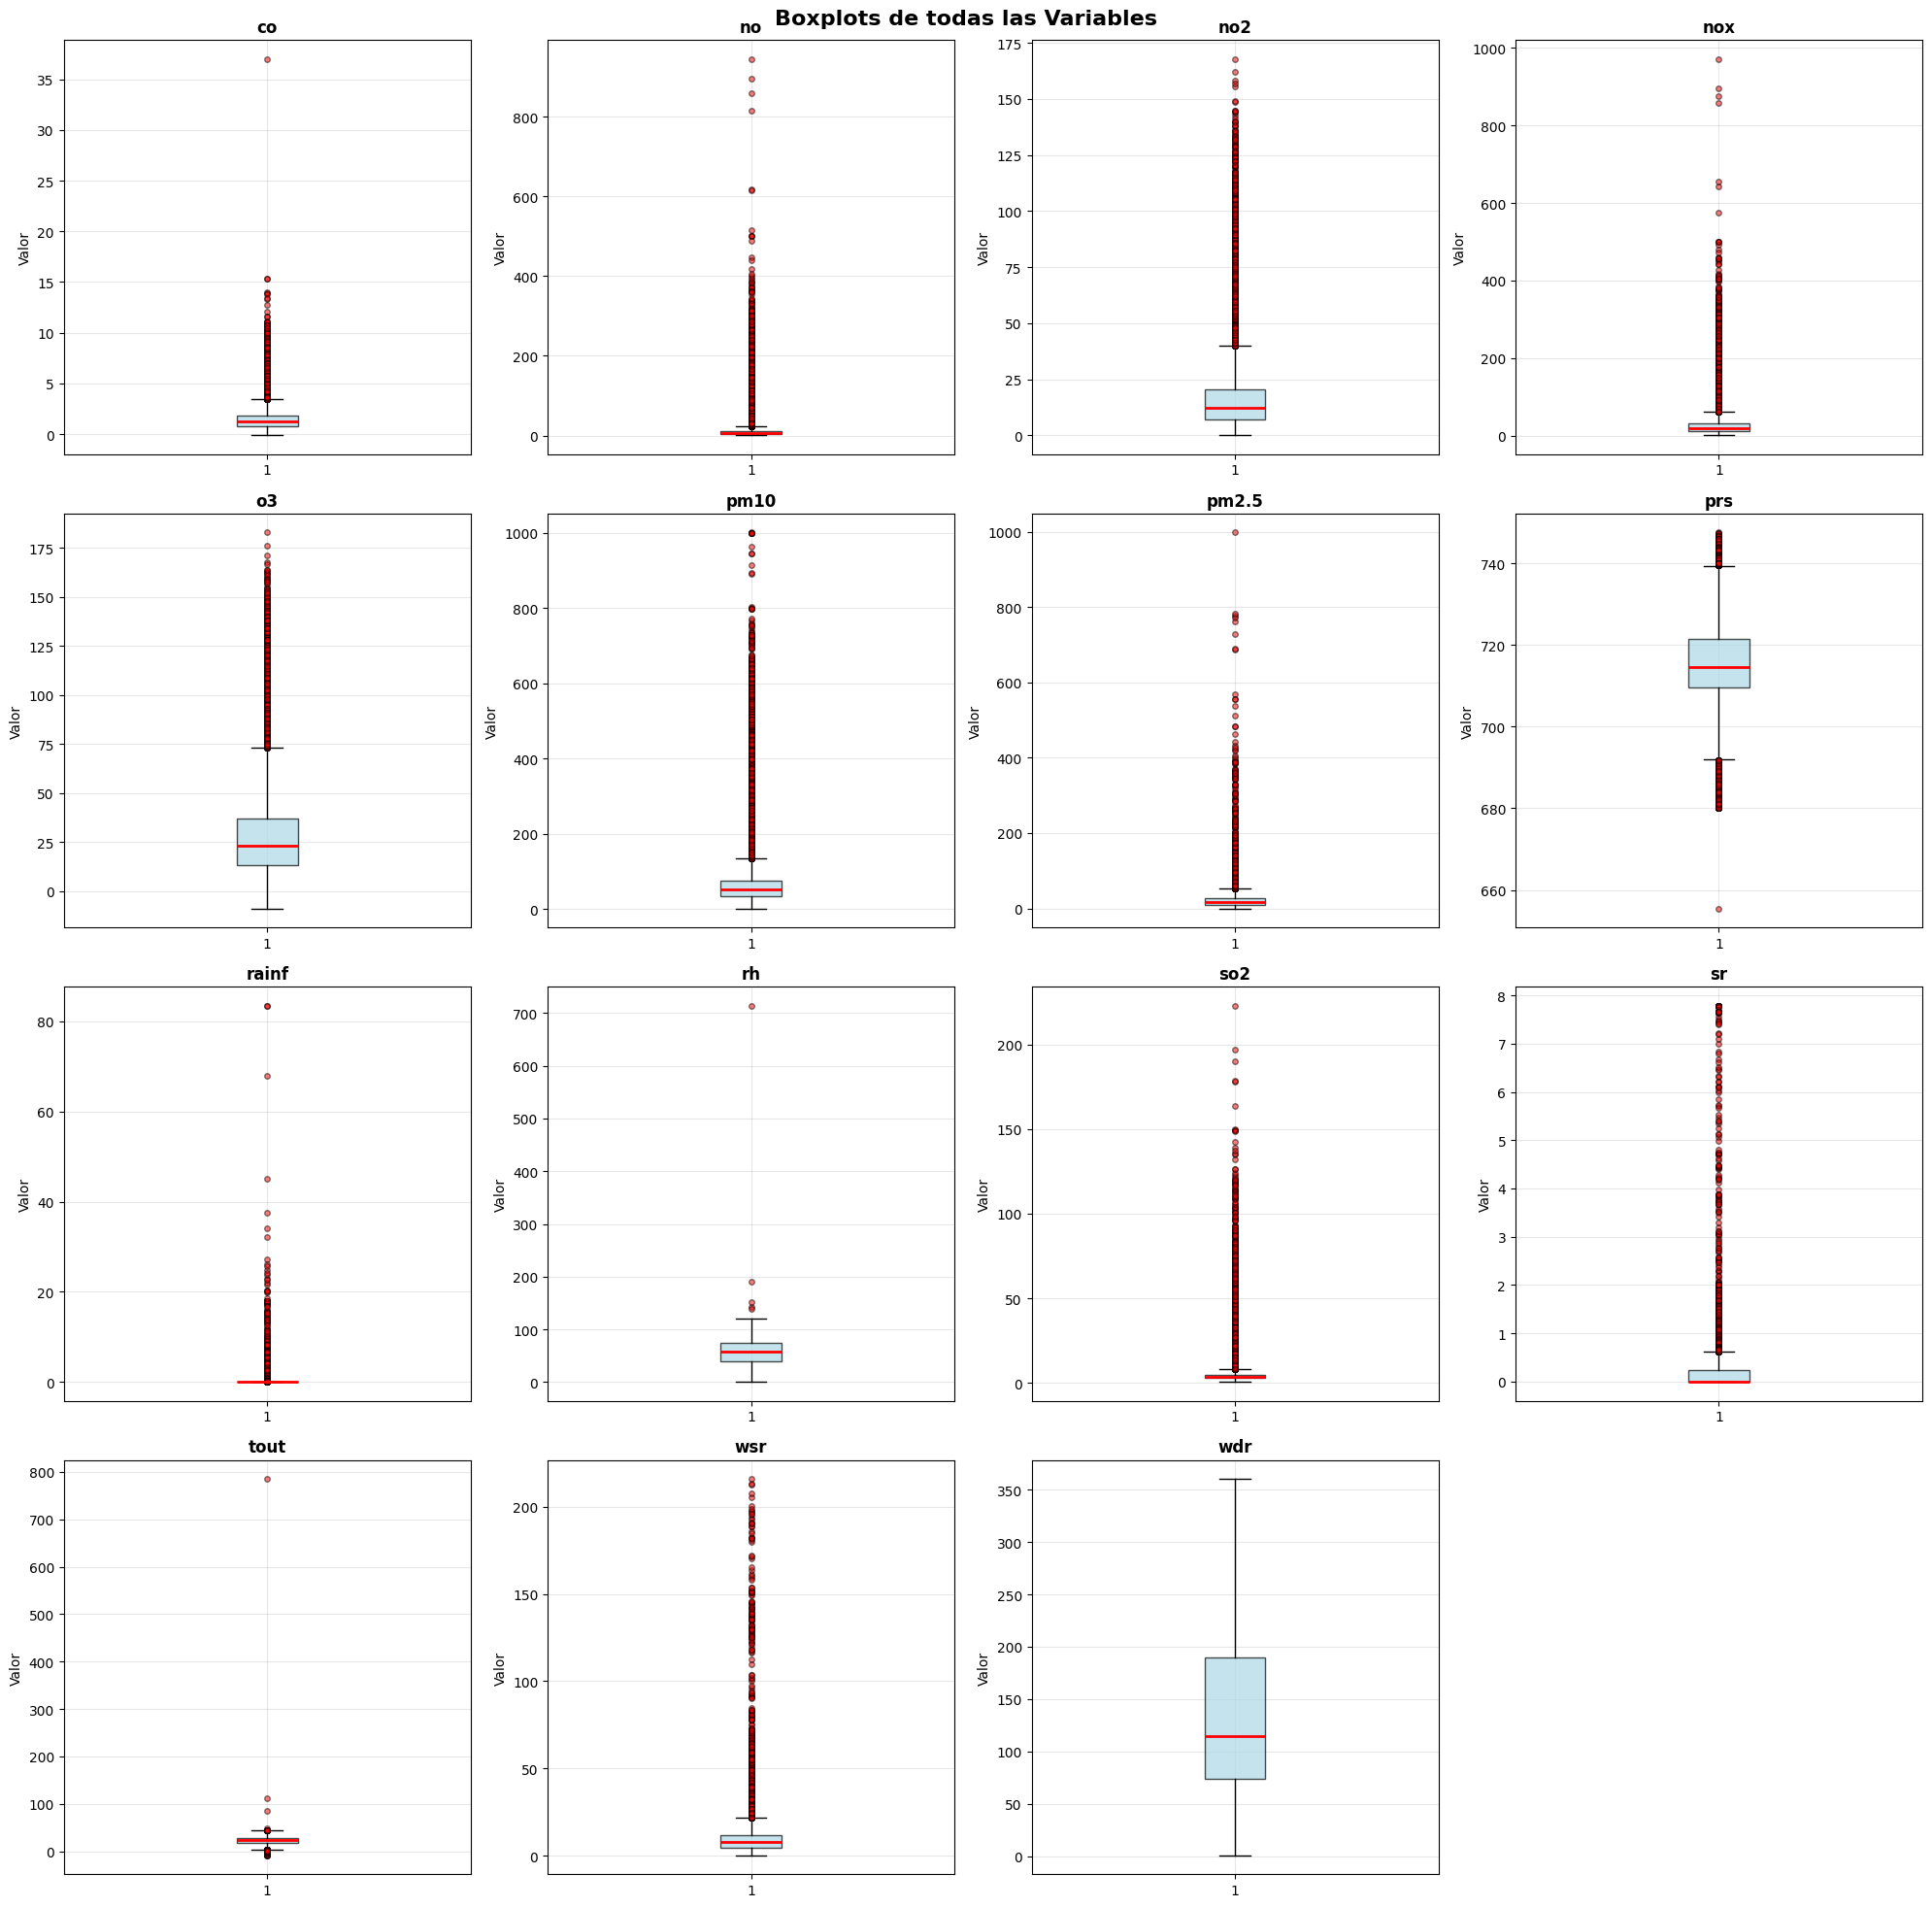


Generando gráficas de z-scores...


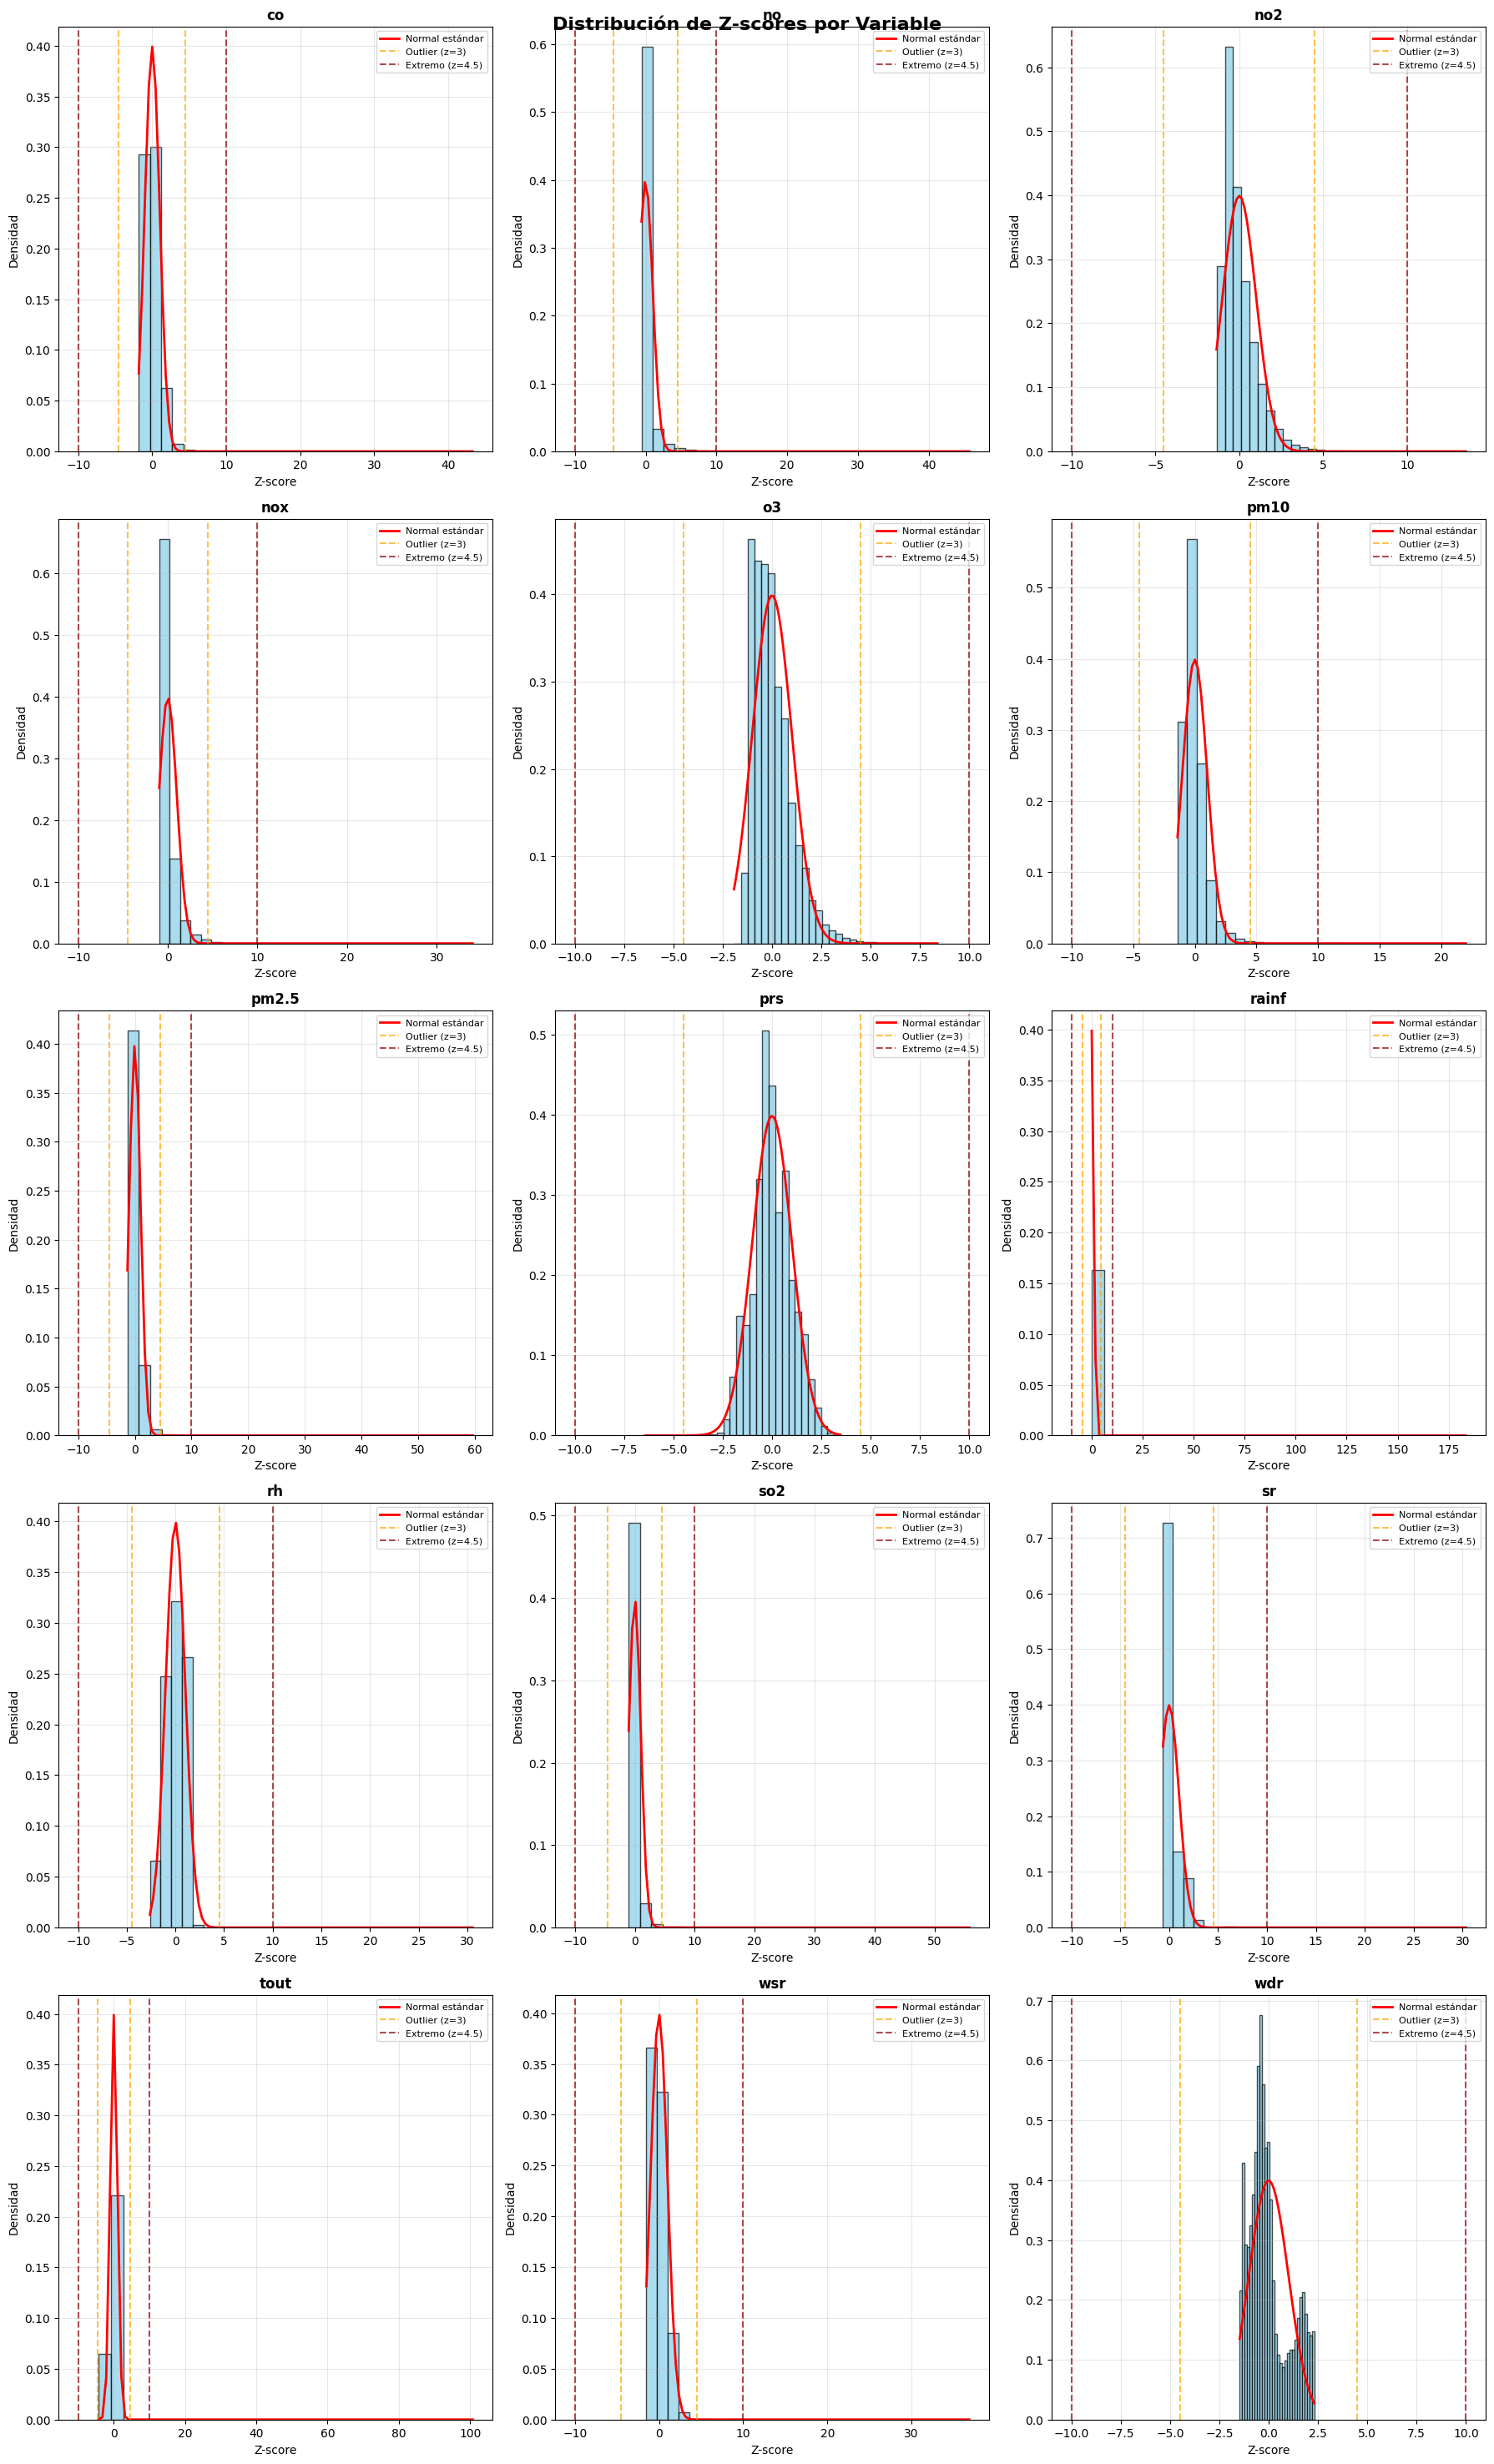

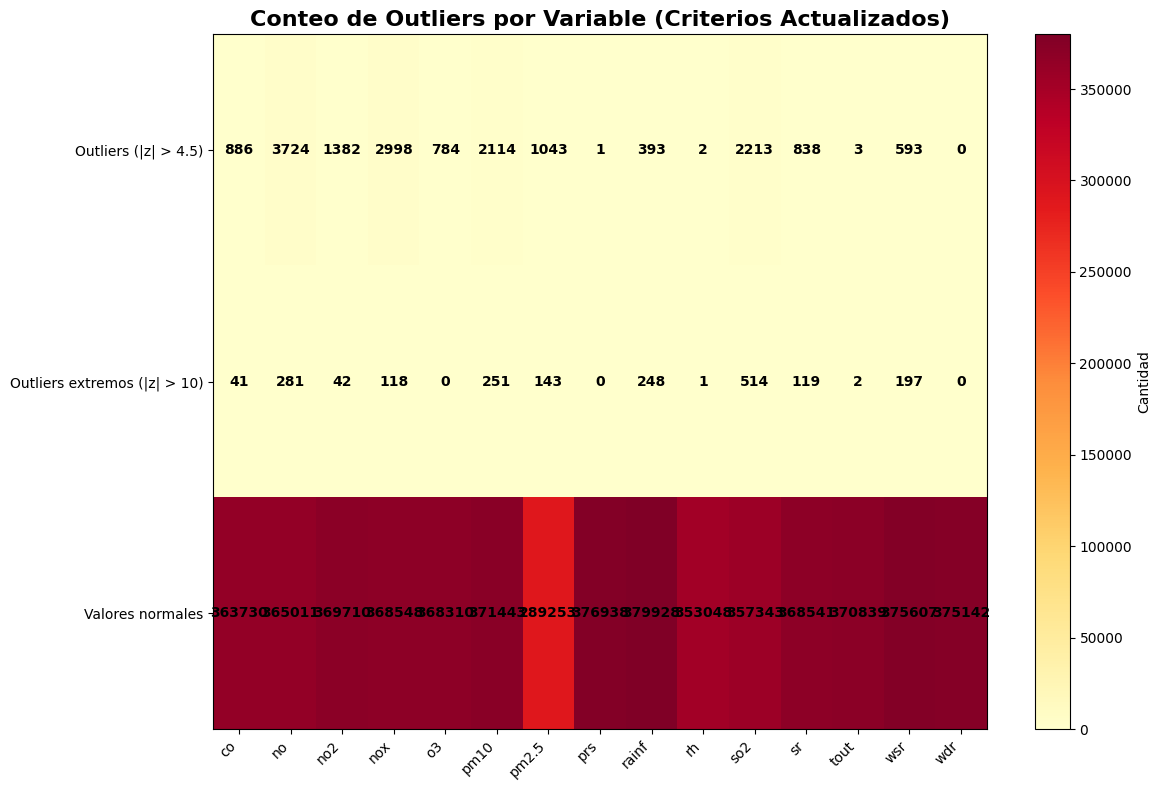


RESUMEN DE ANÁLISIS DE Z-SCORES (CRITERIOS ACTUALIZADOS)

CO:
  • Media: 1.3638
  • Desv. Estándar: 0.8229
  • Rango Z-score: [-1.82, 43.30]
  • Outliers (|z| > 4.5): 886 (0.2%)
  • Outliers extremos (|z| > 10): 41 (0.0%)

NO:
  • Media: 11.9711
  • Desv. Estándar: 20.4146
  • Rango Z-score: [-0.57, 45.71]
  • Outliers (|z| > 4.5): 3724 (1.0%)
  • Outliers extremos (|z| > 10): 281 (0.1%)

NO2:
  • Media: 15.3259
  • Desv. Estándar: 11.2991
  • Rango Z-score: [-1.36, 13.49]
  • Outliers (|z| > 4.5): 1382 (0.4%)
  • Outliers extremos (|z| > 10): 42 (0.0%)

NOX:
  • Media: 27.1126
  • Desv. Estándar: 27.7758
  • Rango Z-score: [-0.96, 34.01]
  • Outliers (|z| > 4.5): 2998 (0.8%)
  • Outliers extremos (|z| > 10): 118 (0.0%)

O3:
  • Media: 26.9284
  • Desv. Estándar: 18.6195
  • Rango Z-score: [-1.93, 8.38]
  • Outliers (|z| > 4.5): 784 (0.2%)
  • Outliers extremos (|z| > 10): 0 (0.0%)

PM10:
  • Media: 60.9569
  • Desv. Estándar: 42.7813
  • Rango Z-score: [-1.40, 21.97]
  • Outliers (|z

In [ ]:
# Configuración de estilo para las gráficas
plt.style.use('default')
sns.set_palette("husl")

# Definir las columnas objetivo
target_columns = ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs', 
                 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']

def calculate_zscores(df, columns):
    """
    Calcula z-scores para las columnas especificadas
    """
    df_zscores = pd.DataFrame()
    zscore_stats = {}
    
    for col in columns:
        if col in df.columns:
            # Eliminar valores nulos para el cálculo
            clean_data = df[col].dropna()
            
            if len(clean_data) > 0:
                # Calcular z-scores
                z_scores = stats.zscore(clean_data)
                
                # Crear DataFrame con índices originales
                z_series = pd.Series(index=clean_data.index, data=z_scores, name=f'{col}_zscore') # type: ignore

                df_zscores = pd.concat([df_zscores, z_series], axis=1)
                
                # Guardar estadísticas con nuevos criterios
                zscore_stats[col] = {
                    'mean': clean_data.mean(),
                    'std': clean_data.std(),
                    'outliers_count': np.sum(np.abs(z_scores) > 4.5),      # Cambiado a z > 3 # type: ignore
                    'extreme_outliers_count': np.sum(np.abs(z_scores) > 10),  # Cambiado a z > 4.5 # type: ignore

                    'min_zscore': z_scores.min(), # type: ignore
                    'max_zscore': z_scores.max() # type: ignore
                }
        else:
            print(f"Advertencia: La columna '{col}' no existe en el DataFrame")
    
    return df_zscores, zscore_stats

def plot_boxplots(df, columns):
    """
    Crea boxplots para todas las variables
    """
    # Filtrar columnas que existen
    existing_cols = [col for col in columns if col in df.columns]
    n_cols = len(existing_cols)
    
    if n_cols == 0:
        print("No se encontraron columnas válidas para graficar")
        return
    
    # Calcular número de filas necesarias (4 columnas por fila)
    n_rows = (n_cols + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
    
    # Si solo hay una fila, asegurar que axes sea un array 2D
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols <= 4:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(existing_cols):
        row = i // 4
        col_idx = i % 4
        
        # Obtener datos limpios
        clean_data = df[col].dropna()
        
        if len(clean_data) > 0:
            # Crear boxplot
            box = axes[row, col_idx].boxplot(clean_data, patch_artist=True, 
                                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                                           medianprops=dict(color='red', linewidth=2),
                                           flierprops=dict(marker='o', markerfacecolor='red', 
                                                         markersize=4, alpha=0.5))
            
            # Configurar gráfica
            axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
            axes[row, col_idx].set_ylabel('Valor')
            axes[row, col_idx].grid(True, alpha=0.3)
            
            # Rotar etiquetas del eje x si es necesario
            axes[row, col_idx].tick_params(axis='x', rotation=0)
    
    # Ocultar ejes vacíos
    for i in range(len(existing_cols), n_rows * 4):
        row = i // 4
        col_idx = i % 4
        axes[row, col_idx].set_visible(False)
    
    plt.suptitle('Boxplots de todas las Variables', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_zscore_analysis(df, df_zscores, columns, stats_dict):
    """
    Crea múltiples visualizaciones para el análisis de z-scores
    """
    # Filtrar columnas que existen
    existing_cols = [col for col in columns if col in df.columns]
    n_cols = len(existing_cols)
    
    if n_cols == 0:
        print("No se encontraron columnas válidas para graficar")
        return
    
    # 1. Distribución de Z-scores - Histogramas individuales por variable
    n_cols = len(existing_cols)
    n_rows = (n_cols + 2) // 3  # 3 columnas por fila
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6*n_rows))
    
    # Si solo hay una fila, asegurar que axes sea un array 2D
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols <= 3:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(existing_cols):
        row = i // 3
        col_idx = i % 3
        
        zscore_col = f'{col}_zscore'
        if zscore_col in df_zscores.columns:
            z_data = df_zscores[zscore_col].dropna()
            
            # Crear histograma
            axes[row, col_idx].hist(z_data, bins=30, alpha=0.7, color='skyblue', 
                                  edgecolor='black', density=True)
            
            # Superponer curva normal estándar
            x = np.linspace(z_data.min(), z_data.max(), 100)
            normal_curve = stats.norm.pdf(x, 0, 1)
            axes[row, col_idx].plot(x, normal_curve, 'r-', linewidth=2, 
                                  label='Normal estándar')
            
            # Líneas de referencia para outliers (actualizadas)
            axes[row, col_idx].axvline(x=4.5, color='orange', linestyle='--', alpha=0.7, label='Outlier (z=3)')
            axes[row, col_idx].axvline(x=-4.5, color='orange', linestyle='--', alpha=0.7)
            axes[row, col_idx].axvline(x=10, color='darkred', linestyle='--', alpha=0.7, label='Extremo (z=4.5)')
            axes[row, col_idx].axvline(x=-10, color='darkred', linestyle='--', alpha=0.7)
            
            # Configurar gráfica
            axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
            axes[row, col_idx].set_xlabel('Z-score')
            axes[row, col_idx].set_ylabel('Densidad')
            axes[row, col_idx].grid(True, alpha=0.3)
            axes[row, col_idx].legend(fontsize=8)
    
    # Ocultar ejes vacíos
    for i in range(len(existing_cols), n_rows * 3):
        row = i // 3
        col_idx = i % 3
        axes[row, col_idx].set_visible(False)
    
    plt.suptitle('Distribución de Z-scores por Variable', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Heatmap de outliers (actualizado)
    if len(existing_cols) > 1:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Crear matriz de outliers con nuevos criterios
        outlier_matrix = np.zeros((len(existing_cols), 3))
        col_names = []
        
        for i, col in enumerate(existing_cols):
            if col in stats_dict:
                outlier_matrix[i, 0] = stats_dict[col]['outliers_count']        # |z| > 3
                outlier_matrix[i, 1] = stats_dict[col]['extreme_outliers_count'] # |z| > 4.5
                outlier_matrix[i, 2] = len(df[col].dropna()) - stats_dict[col]['outliers_count']
                col_names.append(col)
        
        # Crear heatmap
        categories = ['Outliers (|z| > 4.5)', 'Outliers extremos (|z| > 10)', 'Valores normales']
        im = ax.imshow(outlier_matrix.T, cmap='YlOrRd', aspect='auto')
        
        # Configurar ejes
        ax.set_xticks(range(len(col_names)))
        ax.set_xticklabels(col_names, rotation=45, ha='right')
        ax.set_yticks(range(len(categories)))
        ax.set_yticklabels(categories)
        
        # Añadir valores en las celdas
        for i in range(len(categories)):
            for j in range(len(col_names)):
                text = ax.text(j, i, int(outlier_matrix[j, i]), # type: ignore
                             ha="center", va="center", color="black", fontweight='bold')
        
        ax.set_title('Conteo de Outliers por Variable (Criterios Actualizados)', fontsize=16, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Cantidad')
        plt.tight_layout()
        plt.show()
    
    # 3. Gráficas individuales para variables con más outliers (criterio actualizado)
    high_outlier_vars = []
    for col, stats_info in stats_dict.items():
        outlier_percentage = (stats_info['outliers_count'] / len(df[col].dropna())) * 100
        if outlier_percentage > 2:  # Más del 2% de outliers (ajustado para z > 3)
            high_outlier_vars.append((col, outlier_percentage))
    
    if high_outlier_vars:
        n_vars = len(high_outlier_vars)
        n_rows = (n_vars + 1) // 2
        fig, axes = plt.subplots(n_rows, 2, figsize=(15, 6*n_rows))
        
        # Manejar correctamente los casos de arrays de matplotlib
        if n_vars == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = list(axes)
        else:
            axes = axes.flatten()
        
        for i, (col, pct) in enumerate(high_outlier_vars):
            if i < len(axes):
                zscore_col = f'{col}_zscore'
                if zscore_col in df_zscores.columns:
                    # Scatter plot: valor original vs z-score
                    clean_data = df[col].dropna()
                    z_data = df_zscores[zscore_col].dropna()
                    
                    # Asegurar que los índices coincidan
                    common_idx = clean_data.index.intersection(z_data.index)
                    x_vals = clean_data.loc[common_idx]
                    y_vals = z_data.loc[common_idx]
                    
                    # Colorear según nuevos criterios
                    colors = []
                    for z in y_vals:
                        if abs(z) > 4.5:
                            colors.append('darkred')  # Outliers extremos
                        elif abs(z) > 3:
                            colors.append('red')      # Outliers
                        else:
                            colors.append('blue')     # Normales
                    
                    # Usar el eje correcto
                    current_ax = axes[i] if hasattr(axes[i], 'scatter') else axes[i]
                    current_ax.scatter(x_vals, y_vals, c=colors, alpha=0.6, s=30)
                    current_ax.axhline(y=3, color='orange', linestyle='--', alpha=0.7)
                    current_ax.axhline(y=-3, color='orange', linestyle='--', alpha=0.7)
                    current_ax.axhline(y=4.5, color='darkred', linestyle='--', alpha=0.7)
                    current_ax.axhline(y=-4.5, color='darkred', linestyle='--', alpha=0.7)
                    current_ax.set_xlabel(f'Valor original ({col})')
                    current_ax.set_ylabel('Z-score')
                    current_ax.set_title(f'{col} - {pct:.1f}% outliers')
                    current_ax.grid(True, alpha=0.3)
        
        # Ocultar ejes vacíos
        for i in range(len(high_outlier_vars), len(axes)):
            if hasattr(axes[i], 'set_visible'):
                axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()

def print_zscore_summary(stats_dict):
    """
    Imprime un resumen de las estadísticas de z-scores (criterios actualizados)
    """
    print("\n" + "="*80)
    print("RESUMEN DE ANÁLISIS DE Z-SCORES (CRITERIOS ACTUALIZADOS)")
    print("="*80)
    
    for col, stats_info in stats_dict.items():
        total_points = len(df[col].dropna()) if col in df.columns else 0
        outlier_pct = (stats_info['outliers_count'] / total_points) * 100 if total_points > 0 else 0
        extreme_pct = (stats_info['extreme_outliers_count'] / total_points) * 100 if total_points > 0 else 0
        
        print(f"\n{col.upper()}:")
        print(f"  • Media: {stats_info['mean']:.4f}")
        print(f"  • Desv. Estándar: {stats_info['std']:.4f}")
        print(f"  • Rango Z-score: [{stats_info['min_zscore']:.2f}, {stats_info['max_zscore']:.2f}]")
        print(f"  • Outliers (|z| > 4.5): {stats_info['outliers_count']} ({outlier_pct:.1f}%)")
        print(f"  • Outliers extremos (|z| > 10): {stats_info['extreme_outliers_count']} ({extreme_pct:.1f}%)")

# EJECUCIÓN DEL ANÁLISIS
# ======================

# Calcular z-scores
print("Calculando z-scores...")
df_zscores, zscore_stats = calculate_zscores(df, target_columns)

# Mostrar información básica
print(f"\nZ-scores calculados para {len(df_zscores.columns)} variables")
print(f"Forma del DataFrame de z-scores: {df_zscores.shape}")

# Crear boxplots para todas las variables
print("\nGenerando boxplots...")
plot_boxplots(df, target_columns)

# Crear visualizaciones de z-scores
print("\nGenerando gráficas de z-scores...")
plot_zscore_analysis(df, df_zscores, target_columns, zscore_stats)

# Mostrar resumen estadístico
print_zscore_summary(zscore_stats)

print("\n" + "="*80)
print("ANÁLISIS COMPLETADO")
print("="*80)
print("\nCambios realizados:")
print("• Outliers: |z| > 4.5")
print("• Outliers extremos: |z| > 10")
print("• Se agregaron boxplots para todas las variables")
print("\nEl DataFrame 'df_zscores' contiene los z-scores calculados.")
print("Puedes acceder a los z-scores individuales usando df_zscores['variable_zscore']")

Analizando 15 columnas: ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs', 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']
Generando gráficas de análisis de Mahalanobis...


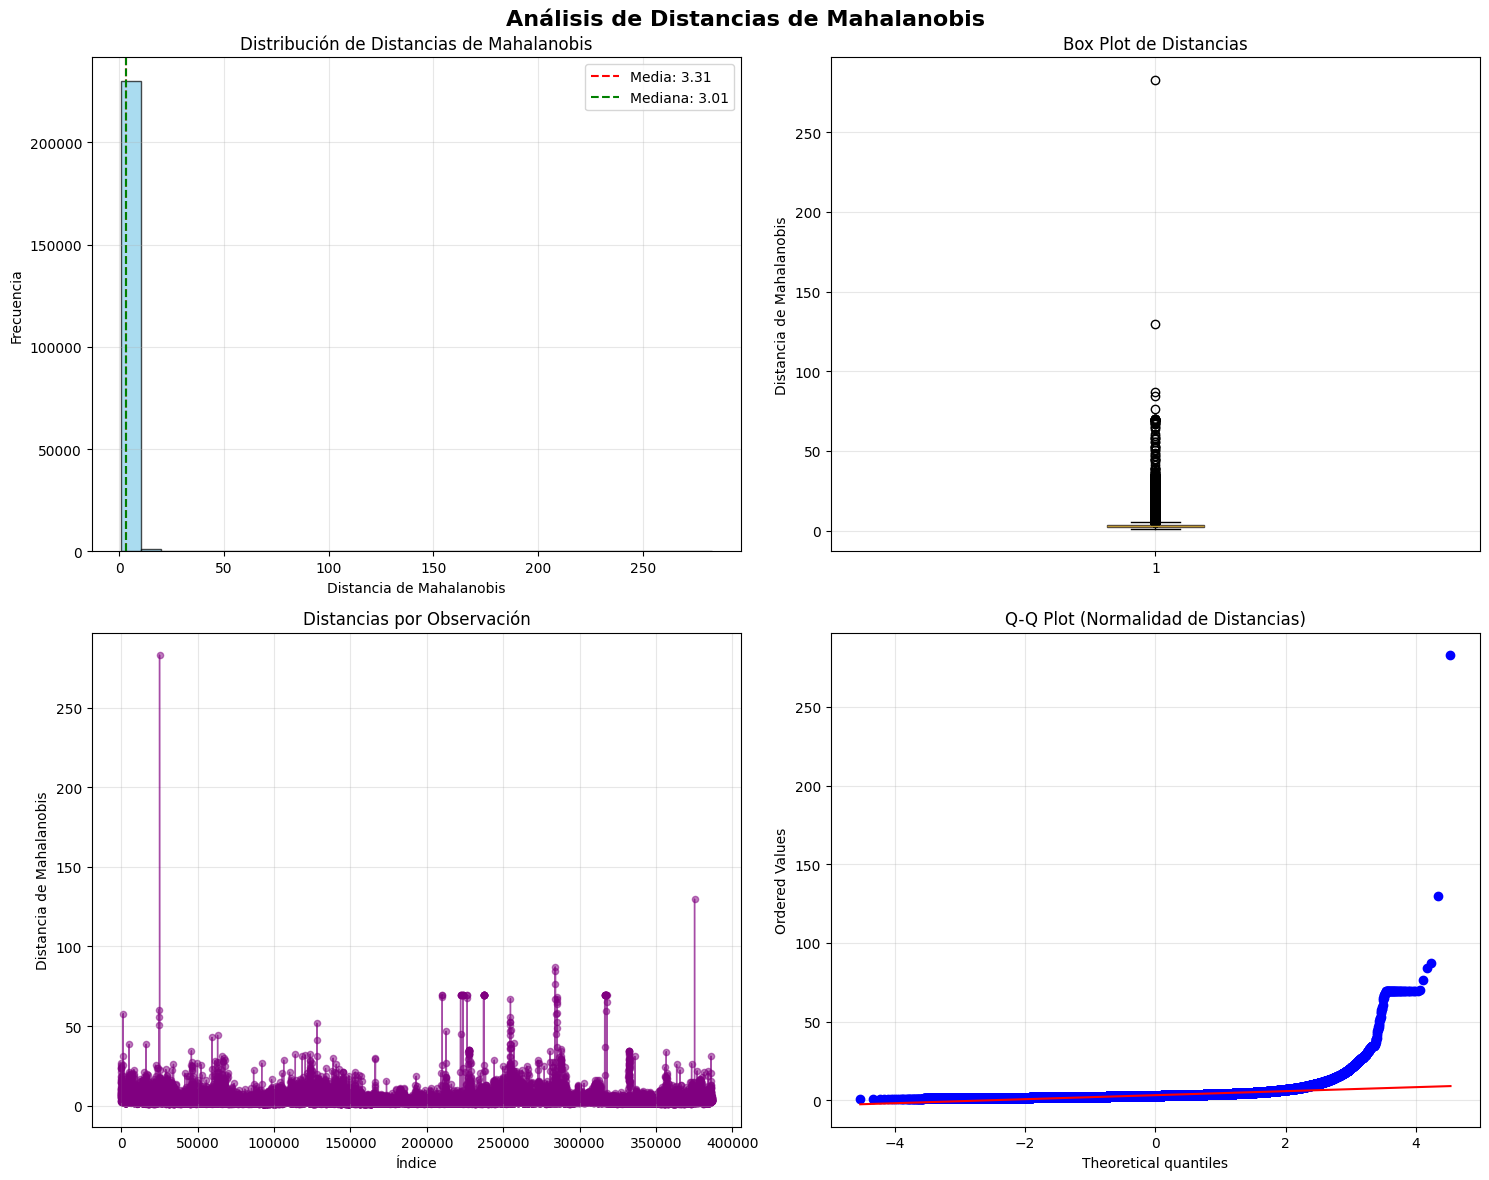


Identificando outliers...

=== ANÁLISIS DE OUTLIERS ===
Umbral (percentil 95): 5.353
Número total de observaciones: 231652
Número de outliers detectados: 11583
Porcentaje de outliers: 5.00%

Top 10 outliers más extremos:
       Índice  Distancia_Mahalanobis
1502    24973             282.940923
11236  375326             129.715835
9394   284063              87.198588
9399   284242              84.404575
9398   284225              76.548727
10529  316468              69.824667
10528  316450              69.745839
10530  316488              69.713492
10527  316430              69.688532
10532  316511              69.676762

Generando heatmap de outliers...


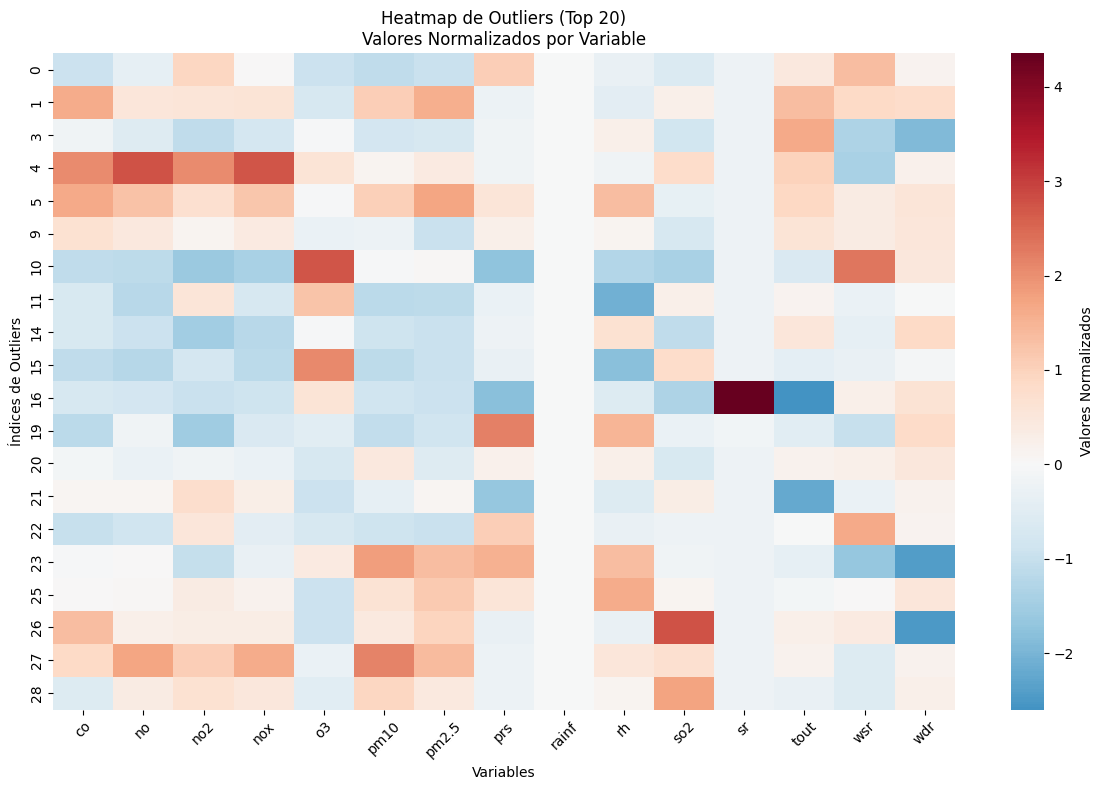


=== ESTADÍSTICAS DE DISTANCIAS ===
Media: 3.311
Mediana: 3.013
Desviación estándar: 2.010
Mínimo: 0.935
Máximo: 282.941
Percentil 25: 2.504
Percentil 75: 3.643
Percentil 95: 5.353
Percentil 99: 8.986


In [31]:

from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler

# Configurar estilo de gráficas
plt.style.use('default')
sns.set_palette("husl")

def calculate_mahalanobis_distances(df, target_columns):
    """
    Calcula las distancias de Mahalanobis para las columnas especificadas
    """
    # Filtrar solo las columnas objetivo y eliminar valores nulos
    data = df[target_columns].dropna()
    
    # Calcular la media y la matriz de covarianza
    mean = np.mean(data, axis=0)
    cov_matrix = np.cov(data.T)
    
    # Calcular la inversa de la matriz de covarianza
    try:
        inv_cov_matrix = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        # Si la matriz no es invertible, usar pseudoinversa
        inv_cov_matrix = np.linalg.pinv(cov_matrix)
        print("Advertencia: Se usó pseudoinversa debido a singularidad de la matriz de covarianza")
    
    # Calcular distancias de Mahalanobis
    distances = []
    for i, row in data.iterrows():
        distance = mahalanobis(row, mean, inv_cov_matrix)
        distances.append(distance)
    
    return np.array(distances), data.index

def plot_mahalanobis_analysis(df, target_columns):
    """
    Crea múltiples visualizaciones de las distancias de Mahalanobis
    """
    # Calcular distancias
    distances, indices = calculate_mahalanobis_distances(df, target_columns)
    
    # Crear figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Análisis de Distancias de Mahalanobis', fontsize=16, fontweight='bold')
    
    # 1. Histograma de distancias
    axes[0, 0].hist(distances, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(np.mean(distances), color='red', linestyle='--', 
                       label=f'Media: {np.mean(distances):.2f}')
    axes[0, 0].axvline(np.median(distances), color='green', linestyle='--', 
                       label=f'Mediana: {np.median(distances):.2f}')
    axes[0, 0].set_xlabel('Distancia de Mahalanobis')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Distancias de Mahalanobis')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Box plot de distancias
    axes[0, 1].boxplot(distances, patch_artist=True, 
                       boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[0, 1].set_ylabel('Distancia de Mahalanobis')
    axes[0, 1].set_title('Box Plot de Distancias')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Gráfico de serie temporal (si hay índice temporal)
    axes[1, 0].plot(indices, distances, alpha=0.7, color='purple', linewidth=1)
    axes[1, 0].scatter(indices, distances, alpha=0.5, s=20, color='purple')
    axes[1, 0].set_xlabel('Índice')
    axes[1, 0].set_ylabel('Distancia de Mahalanobis')
    axes[1, 0].set_title('Distancias por Observación')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Q-Q plot para verificar normalidad
    stats.probplot(distances, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normalidad de Distancias)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return distances, indices

def identify_outliers(df, target_columns, threshold_percentile=95):
    """
    Identifica outliers basado en las distancias de Mahalanobis
    """
    distances, indices = calculate_mahalanobis_distances(df, target_columns)
    
    # Calcular umbral basado en percentil
    threshold = np.percentile(distances, threshold_percentile)
    
    # Identificar outliers
    outliers_mask = distances > threshold
    outliers_indices = indices[outliers_mask]
    outliers_distances = distances[outliers_mask]
    
    print(f"\n=== ANÁLISIS DE OUTLIERS ===")
    print(f"Umbral (percentil {threshold_percentile}): {threshold:.3f}")
    print(f"Número total de observaciones: {len(distances)}")
    print(f"Número de outliers detectados: {len(outliers_indices)}")
    print(f"Porcentaje de outliers: {len(outliers_indices)/len(distances)*100:.2f}%")
    
    if len(outliers_indices) > 0:
        print(f"\nTop 10 outliers más extremos:")
        outliers_df = pd.DataFrame({
            'Índice': outliers_indices,
            'Distancia_Mahalanobis': outliers_distances
        }).sort_values('Distancia_Mahalanobis', ascending=False)
        print(outliers_df.head(10))
    
    return outliers_indices, outliers_distances, threshold

def plot_outliers_heatmap(df, target_columns, outliers_indices):
    """
    Crea un heatmap de los outliers para visualizar patrones
    """
    if len(outliers_indices) == 0:
        print("No hay outliers para visualizar")
        return
    
    # Tomar solo los primeros 20 outliers más extremos para visualización
    outliers_data = df.loc[outliers_indices, target_columns].head(20)
    
    # Normalizar los datos para mejor visualización
    scaler = StandardScaler()
    normalized_data = scaler.fit_transform(outliers_data)
    normalized_df = pd.DataFrame(normalized_data, 
                                columns=target_columns, 
                                index=outliers_data.index)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(normalized_df, 
                cmap='RdBu_r', 
                center=0,
                cbar_kws={'label': 'Valores Normalizados'},
                fmt='.2f')
    plt.title('Heatmap de Outliers (Top 20)\nValores Normalizados por Variable')
    plt.xlabel('Variables')
    plt.ylabel('Índices de Outliers')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Columnas objetivo
target_columns = ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs',
                 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']

# Verificar que las columnas existan en el DataFrame
missing_columns = [col for col in target_columns if col not in df.columns]
if missing_columns:
    print(f"Advertencia: Las siguientes columnas no están en el DataFrame: {missing_columns}")
    target_columns = [col for col in target_columns if col in df.columns]

print(f"Analizando {len(target_columns)} columnas: {target_columns}")

# Ejecutar análisis principal
print("Generando gráficas de análisis de Mahalanobis...")
distances, indices = plot_mahalanobis_analysis(df, target_columns)

# Identificar outliers
print("\nIdentificando outliers...")
outliers_indices, outliers_distances, threshold = identify_outliers(df, target_columns, threshold_percentile=95)

# Visualizar outliers en heatmap
if len(outliers_indices) > 0:
    print("\nGenerando heatmap de outliers...")
    plot_outliers_heatmap(df, target_columns, outliers_indices)

# Estadísticas adicionales
print(f"\n=== ESTADÍSTICAS DE DISTANCIAS ===")
print(f"Media: {np.mean(distances):.3f}")
print(f"Mediana: {np.median(distances):.3f}")
print(f"Desviación estándar: {np.std(distances):.3f}")
print(f"Mínimo: {np.min(distances):.3f}")
print(f"Máximo: {np.max(distances):.3f}")
print(f"Percentil 25: {np.percentile(distances, 25):.3f}")
print(f"Percentil 75: {np.percentile(distances, 75):.3f}")
print(f"Percentil 95: {np.percentile(distances, 95):.3f}")
print(f"Percentil 99: {np.percentile(distances, 99):.3f}")

=== FILTRADO POR DISTANCIA DE MAHALANOBIS ===
Umbral de filtrado: 100
Tamaño original del DataFrame: 386492 filas
Filas con datos completos para análisis: 231648

Filas con distancia > 100: 0

=== RESULTADOS DEL FILTRADO ===
Tamaño del DataFrame: 386492 filas (ninguna fila eliminada)
Valores originales no nulos: 5470305
Valores no nulos después del filtrado: 5470305
Valores reemplazados con NaN: 0
Porcentaje de valores conservados: 100.00%


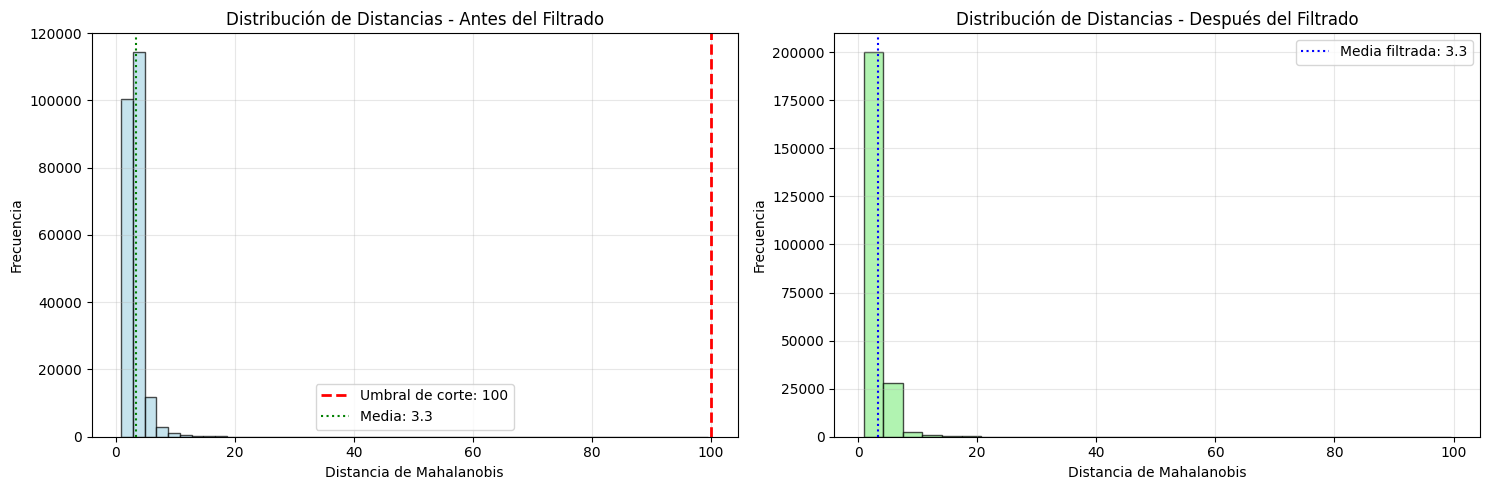


=== ESTADÍSTICAS COMPARATIVAS ===
ANTES DEL FILTRADO:
  - Número de observaciones: 231648
  - Media: 3.347
  - Mediana: 3.050
  - Máximo: 99.508
  - Desv. estándar: 1.948

DESPUÉS DEL FILTRADO:
  - Número de observaciones: 231648
  - Media: 3.347
  - Mediana: 3.050
  - Máximo: 99.508
  - Desv. estándar: 1.948

✅ DataFrame actualizado exitosamente!
El DataFrame 'df' ahora contiene 386492 filas (ninguna eliminada)
Valores reemplazados con NaN: 0


In [34]:
def filter_by_mahalanobis_preserve_rows(df, target_columns, threshold=100):
    """
    Filtra el DataFrame reemplazando valores atípicos con NaN en lugar de eliminar filas
    """
    print(f"=== FILTRADO POR DISTANCIA DE MAHALANOBIS ===")
    print(f"Umbral de filtrado: {threshold}")
    print(f"Tamaño original del DataFrame: {len(df)} filas")
    
    # Verificar que las columnas existan
    missing_columns = [col for col in target_columns if col not in df.columns]
    if missing_columns:
        print(f"Advertencia: Las siguientes columnas no están en el DataFrame: {missing_columns}")
        target_columns = [col for col in target_columns if col in df.columns]
    
    # Crear una copia del DataFrame original
    df_modified = df.copy()
    
    # Filtrar solo las columnas objetivo y eliminar valores nulos para el análisis
    data_for_analysis = df[target_columns].dropna()
    valid_indices = data_for_analysis.index
    
    print(f"Filas con datos completos para análisis: {len(data_for_analysis)}")
    
    if len(data_for_analysis) == 0:
        print("Error: No hay datos válidos para el análisis")
        return df, np.array([]), np.array([])
    
    # Calcular la media y la matriz de covarianza
    mean = np.mean(data_for_analysis, axis=0)
    cov_matrix = np.cov(data_for_analysis.T)
    
    # Calcular la inversa de la matriz de covarianza
    try:
        inv_cov_matrix = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        # Si la matriz no es invertible, usar pseudoinversa
        inv_cov_matrix = np.linalg.pinv(cov_matrix)
        print("Advertencia: Se usó pseudoinversa debido a singularidad de la matriz de covarianza")
    
    # Calcular distancias de Mahalanobis
    distances = []
    indices_with_distances = []
    
    for i, (idx, row) in enumerate(data_for_analysis.iterrows()):
        distance = mahalanobis(row, mean, inv_cov_matrix)
        distances.append(distance)
        indices_with_distances.append(idx)
    
    distances = np.array(distances)
    indices_with_distances = np.array(indices_with_distances)
    
    # Identificar filas atípicas
    outliers_mask = distances > threshold
    outliers_indices = indices_with_distances[outliers_mask]
    outliers_distances = distances[outliers_mask]
    
    print(f"\nFilas con distancia > {threshold}: {len(outliers_indices)}")
    
    if len(outliers_indices) > 0:
        print(f"Porcentaje de filas atípicas: {len(outliers_indices)/len(data_for_analysis)*100:.2f}%")
        print(f"\nTop 10 observaciones más extremas:")
        extreme_df = pd.DataFrame({
            'Índice': outliers_indices,
            'Distancia_Mahalanobis': outliers_distances
        }).sort_values('Distancia_Mahalanobis', ascending=False)
        print(extreme_df.head(10))
        
        # Reemplazar valores atípicos con NaN en las columnas objetivo
        df_modified.loc[outliers_indices, target_columns] = np.nan
        print(f"\n✅ Valores atípicos reemplazados con NaN en {len(outliers_indices)} filas")
    
    # Contar cuántos valores se han reemplazado
    original_non_null_count = df[target_columns].count().sum()
    modified_non_null_count = df_modified[target_columns].count().sum()
    values_replaced = original_non_null_count - modified_non_null_count
    
    print(f"\n=== RESULTADOS DEL FILTRADO ===")
    print(f"Tamaño del DataFrame: {len(df_modified)} filas (ninguna fila eliminada)")
    print(f"Valores originales no nulos: {original_non_null_count}")
    print(f"Valores no nulos después del filtrado: {modified_non_null_count}")
    print(f"Valores reemplazados con NaN: {values_replaced}")
    print(f"Porcentaje de valores conservados: {modified_non_null_count/original_non_null_count*100:.2f}%")
    
    return df_modified, distances, indices_with_distances

# Función para visualizar (se mantiene igual)
def plot_filtering_comparison(distances, indices_with_distances, threshold=100):
    """
    Visualiza el efecto del filtrado
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico 1: Histograma con línea de corte
    axes[0].hist(distances, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
    axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, 
                    label=f'Umbral de corte: {threshold}')
    axes[0].axvline(np.mean(distances), color='green', linestyle=':', 
                    label=f'Media: {np.mean(distances):.1f}')
    axes[0].set_xlabel('Distancia de Mahalanobis')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución de Distancias - Antes del Filtrado')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Crear datos filtrados para el segundo gráfico
    filtered_distances = distances[distances <= threshold]
    
    # Gráfico 2: Histograma después del filtrado
    axes[1].hist(filtered_distances, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1].axvline(np.mean(filtered_distances), color='blue', linestyle=':', 
                    label=f'Media filtrada: {np.mean(filtered_distances):.1f}')
    axes[1].set_xlabel('Distancia de Mahalanobis')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Distancias - Después del Filtrado')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas comparativas
    print(f"\n=== ESTADÍSTICAS COMPARATIVAS ===")
    print(f"ANTES DEL FILTRADO:")
    print(f"  - Número de observaciones: {len(distances)}")
    print(f"  - Media: {np.mean(distances):.3f}")
    print(f"  - Mediana: {np.median(distances):.3f}")
    print(f"  - Máximo: {np.max(distances):.3f}")
    print(f"  - Desv. estándar: {np.std(distances):.3f}")
    
    print(f"\nDESPUÉS DEL FILTRADO:")
    print(f"  - Número de observaciones: {len(filtered_distances)}")
    print(f"  - Media: {np.mean(filtered_distances):.3f}")
    print(f"  - Mediana: {np.median(filtered_distances):.3f}")
    print(f"  - Máximo: {np.max(filtered_distances):.3f}")
    print(f"  - Desv. estándar: {np.std(filtered_distances):.3f}")

# Columnas objetivo
target_columns = ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs',
                 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']

# Aplicar el filtrado preservando filas
df_modified, distances, indices_with_distances = filter_by_mahalanobis_preserve_rows(df, target_columns, threshold=100)

# Visualizar el efecto del filtrado
plot_filtering_comparison(distances, indices_with_distances, threshold=100)

# Actualizar el DataFrame original
df = df_modified.copy()

print(f"\n✅ DataFrame actualizado exitosamente!")
print(f"El DataFrame 'df' ahora contiene {len(df)} filas (ninguna eliminada)")
print(f"Valores reemplazados con NaN: {df[target_columns].isna().sum().sum() - df[target_columns].isna().sum().sum()}")

# Opcional: Guardar una copia del DataFrame modificado
# df_modified.to_csv('datos_filtrados_mahalanobis_preservado.csv', index=False)
# print("💾 Datos filtrados guardados en 'datos_filtrados_mahalanobis_preservado.csv'")

Analizando 15 columnas: ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs', 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']
Generando gráficas de análisis de Mahalanobis...


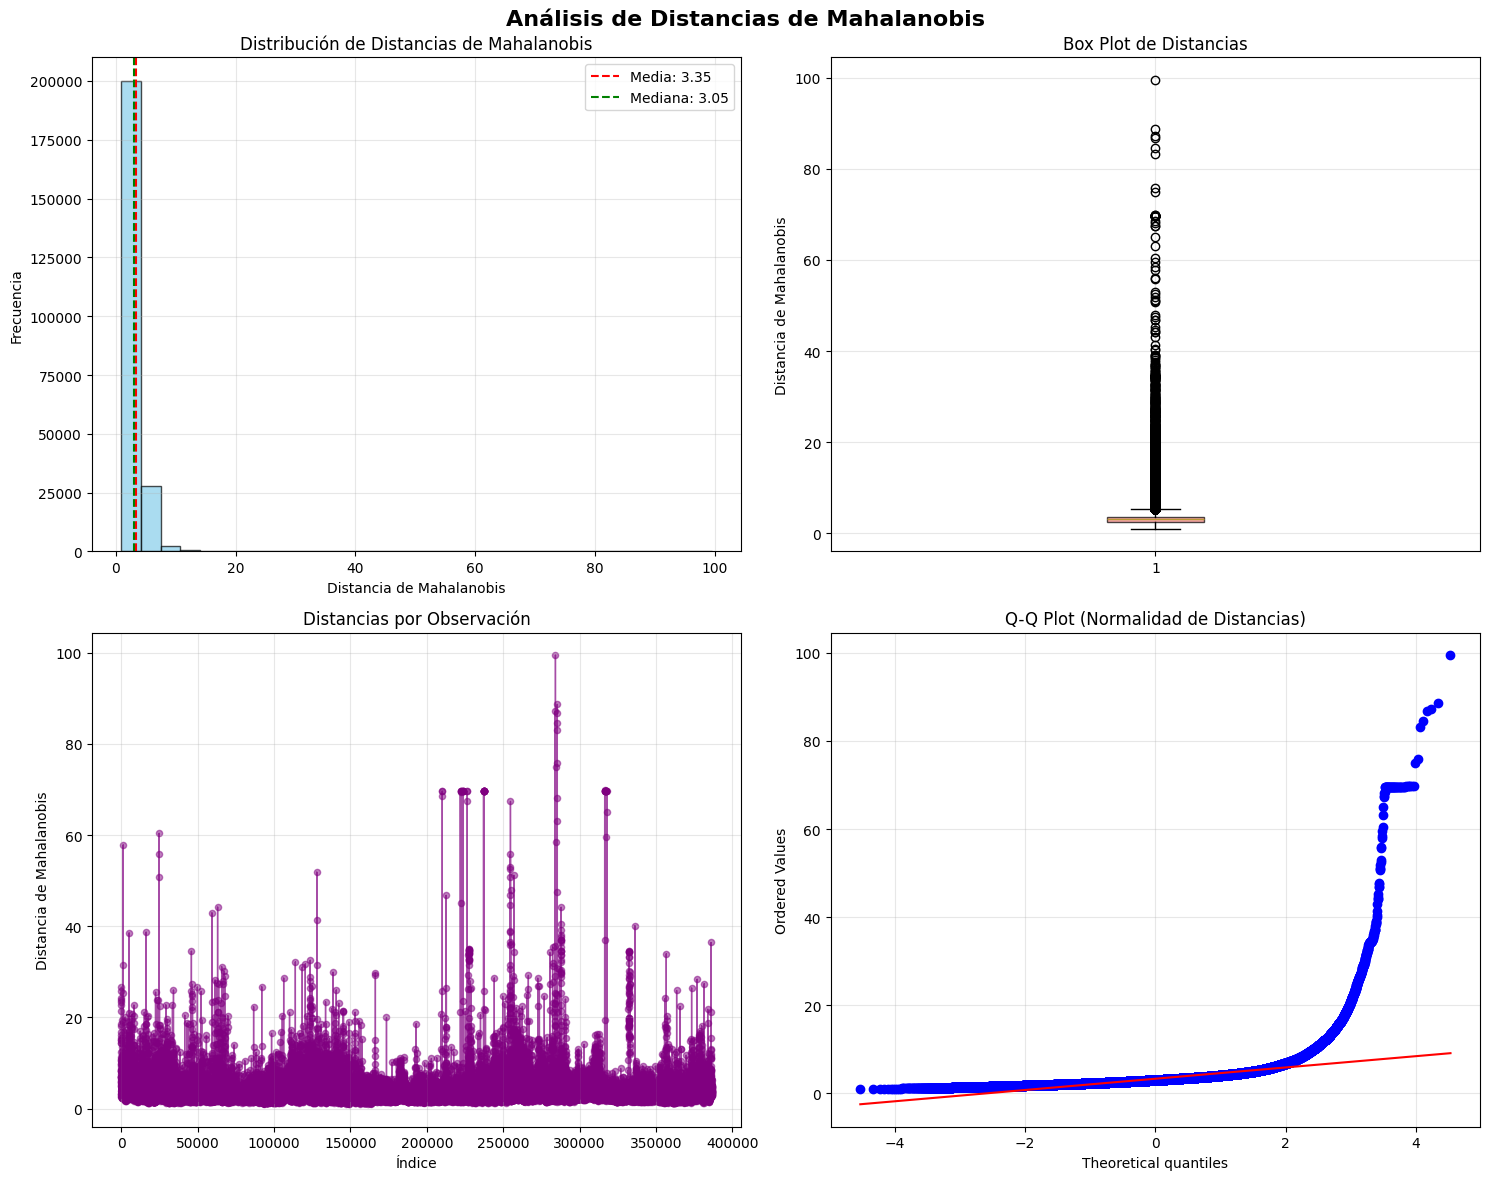


Identificando outliers...

=== ANÁLISIS DE OUTLIERS ===
Umbral (percentil 95): 5.393
Número total de observaciones: 231648
Número de outliers detectados: 11583
Porcentaje de outliers: 5.00%

Top 10 outliers más extremos:
       Índice  Distancia_Mahalanobis
9394   284225              99.508423
9446   285454              88.696270
9390   284055              87.199925
9444   285359              86.726482
9445   285372              84.552676
9442   285342              83.129475
9447   285460              75.857970
9415   284848              74.905386
10524  316468              69.824803
10523  316450              69.745407

Generando heatmap de outliers...


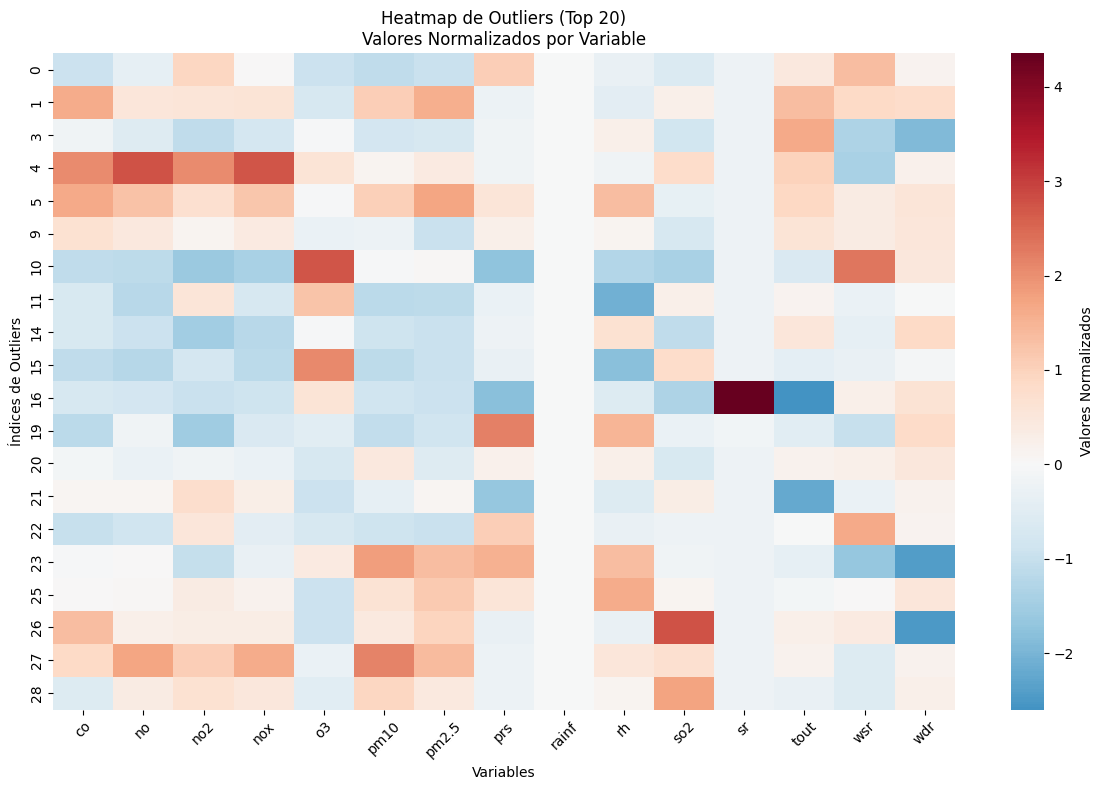


=== ESTADÍSTICAS DE DISTANCIAS ===
Media: 3.347
Mediana: 3.050
Desviación estándar: 1.948
Mínimo: 0.942
Máximo: 99.508
Percentil 25: 2.538
Percentil 75: 3.682
Percentil 95: 5.393
Percentil 99: 9.048


In [35]:

from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler

# Configurar estilo de gráficas
plt.style.use('default')
sns.set_palette("husl")

def calculate_mahalanobis_distances(df, target_columns):
    """
    Calcula las distancias de Mahalanobis para las columnas especificadas
    """
    # Filtrar solo las columnas objetivo y eliminar valores nulos
    data = df[target_columns].dropna()
    
    # Calcular la media y la matriz de covarianza
    mean = np.mean(data, axis=0)
    cov_matrix = np.cov(data.T)
    
    # Calcular la inversa de la matriz de covarianza
    try:
        inv_cov_matrix = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        # Si la matriz no es invertible, usar pseudoinversa
        inv_cov_matrix = np.linalg.pinv(cov_matrix)
        print("Advertencia: Se usó pseudoinversa debido a singularidad de la matriz de covarianza")
    
    # Calcular distancias de Mahalanobis
    distances = []
    for i, row in data.iterrows():
        distance = mahalanobis(row, mean, inv_cov_matrix)
        distances.append(distance)
    
    return np.array(distances), data.index

def plot_mahalanobis_analysis(df, target_columns):
    """
    Crea múltiples visualizaciones de las distancias de Mahalanobis
    """
    # Calcular distancias
    distances, indices = calculate_mahalanobis_distances(df, target_columns)
    
    # Crear figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Análisis de Distancias de Mahalanobis', fontsize=16, fontweight='bold')
    
    # 1. Histograma de distancias
    axes[0, 0].hist(distances, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(np.mean(distances), color='red', linestyle='--', 
                       label=f'Media: {np.mean(distances):.2f}')
    axes[0, 0].axvline(np.median(distances), color='green', linestyle='--', 
                       label=f'Mediana: {np.median(distances):.2f}')
    axes[0, 0].set_xlabel('Distancia de Mahalanobis')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Distancias de Mahalanobis')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Box plot de distancias
    axes[0, 1].boxplot(distances, patch_artist=True, 
                       boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[0, 1].set_ylabel('Distancia de Mahalanobis')
    axes[0, 1].set_title('Box Plot de Distancias')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Gráfico de serie temporal (si hay índice temporal)
    axes[1, 0].plot(indices, distances, alpha=0.7, color='purple', linewidth=1)
    axes[1, 0].scatter(indices, distances, alpha=0.5, s=20, color='purple')
    axes[1, 0].set_xlabel('Índice')
    axes[1, 0].set_ylabel('Distancia de Mahalanobis')
    axes[1, 0].set_title('Distancias por Observación')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Q-Q plot para verificar normalidad
    stats.probplot(distances, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normalidad de Distancias)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return distances, indices

def identify_outliers(df, target_columns, threshold_percentile=95):
    """
    Identifica outliers basado en las distancias de Mahalanobis
    """
    distances, indices = calculate_mahalanobis_distances(df, target_columns)
    
    # Calcular umbral basado en percentil
    threshold = np.percentile(distances, threshold_percentile)
    
    # Identificar outliers
    outliers_mask = distances > threshold
    outliers_indices = indices[outliers_mask]
    outliers_distances = distances[outliers_mask]
    
    print(f"\n=== ANÁLISIS DE OUTLIERS ===")
    print(f"Umbral (percentil {threshold_percentile}): {threshold:.3f}")
    print(f"Número total de observaciones: {len(distances)}")
    print(f"Número de outliers detectados: {len(outliers_indices)}")
    print(f"Porcentaje de outliers: {len(outliers_indices)/len(distances)*100:.2f}%")
    
    if len(outliers_indices) > 0:
        print(f"\nTop 10 outliers más extremos:")
        outliers_df = pd.DataFrame({
            'Índice': outliers_indices,
            'Distancia_Mahalanobis': outliers_distances
        }).sort_values('Distancia_Mahalanobis', ascending=False)
        print(outliers_df.head(10))
    
    return outliers_indices, outliers_distances, threshold

def plot_outliers_heatmap(df, target_columns, outliers_indices):
    """
    Crea un heatmap de los outliers para visualizar patrones
    """
    if len(outliers_indices) == 0:
        print("No hay outliers para visualizar")
        return
    
    # Tomar solo los primeros 20 outliers más extremos para visualización
    outliers_data = df.loc[outliers_indices, target_columns].head(20)
    
    # Normalizar los datos para mejor visualización
    scaler = StandardScaler()
    normalized_data = scaler.fit_transform(outliers_data)
    normalized_df = pd.DataFrame(normalized_data, 
                                columns=target_columns, 
                                index=outliers_data.index)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(normalized_df, 
                cmap='RdBu_r', 
                center=0,
                cbar_kws={'label': 'Valores Normalizados'},
                fmt='.2f')
    plt.title('Heatmap de Outliers (Top 20)\nValores Normalizados por Variable')
    plt.xlabel('Variables')
    plt.ylabel('Índices de Outliers')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Columnas objetivo
target_columns = ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2.5', 'prs',
                 'rainf', 'rh', 'so2', 'sr', 'tout', 'wsr', 'wdr']

# Verificar que las columnas existan en el DataFrame
missing_columns = [col for col in target_columns if col not in df.columns]
if missing_columns:
    print(f"Advertencia: Las siguientes columnas no están en el DataFrame: {missing_columns}")
    target_columns = [col for col in target_columns if col in df.columns]

print(f"Analizando {len(target_columns)} columnas: {target_columns}")

# Ejecutar análisis principal
print("Generando gráficas de análisis de Mahalanobis...")
distances, indices = plot_mahalanobis_analysis(df, target_columns)

# Identificar outliers
print("\nIdentificando outliers...")
outliers_indices, outliers_distances, threshold = identify_outliers(df, target_columns, threshold_percentile=95)

# Visualizar outliers en heatmap
if len(outliers_indices) > 0:
    print("\nGenerando heatmap de outliers...")
    plot_outliers_heatmap(df, target_columns, outliers_indices)

# Estadísticas adicionales
print(f"\n=== ESTADÍSTICAS DE DISTANCIAS ===")
print(f"Media: {np.mean(distances):.3f}")
print(f"Mediana: {np.median(distances):.3f}")
print(f"Desviación estándar: {np.std(distances):.3f}")
print(f"Mínimo: {np.min(distances):.3f}")
print(f"Máximo: {np.max(distances):.3f}")
print(f"Percentil 25: {np.percentile(distances, 25):.3f}")
print(f"Percentil 75: {np.percentile(distances, 75):.3f}")
print(f"Percentil 95: {np.percentile(distances, 95):.3f}")
print(f"Percentil 99: {np.percentile(distances, 99):.3f}")

In [6]:
import pandas as pd
import numpy as np
import os
from scipy.stats import chi2, zscore
from scipy.spatial.distance import mahalanobis

def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method (simpler and more appropriate for univariate data).
    
    Parameters:
    -----------
    data : array-like
        The data to check for outliers (should be non-null values)
    threshold : float
        Z-score threshold for outlier detection (default 3, meaning 3 standard deviations)
    
    Returns:
    --------
    outliers : boolean array
        True for outliers, False otherwise
    """
    if len(data) < 2:
        return np.zeros(len(data), dtype=bool)
    
    # Handle case where all values are the same (zero variance)
    if np.std(data) == 0:
        return np.zeros(len(data), dtype=bool)
    
    # Calculate Z-scores
    z_scores = np.abs(zscore(data))
    
    # Identify outliers
    outliers = z_scores > threshold
    
    return outliers

def detect_outliers_iqr(data, k=1.5):
    """
    Detect outliers using Interquartile Range (IQR) method.
    
    Parameters:
    -----------
    data : array-like
        The data to check for outliers (should be non-null values)
    k : float
        IQR multiplier for outlier detection (default 1.5)
    
    Returns:
    --------
    outliers : boolean array
        True for outliers, False otherwise
    """
    if len(data) < 4:  # Need at least 4 points for quartiles
        return np.zeros(len(data), dtype=bool)
    
    data = np.array(data)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    # Define outlier bounds
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    
    # Identify outliers
    outliers = (data < lower_bound) | (data > upper_bound)
    
    return outliers

def detect_outliers_mahalanobis(data, alpha=0.005):
    """
    Detect outliers using Mahalanobis distance with given alpha level.
    (Keep original method as backup)
    """
    if len(data) < 2:
        return np.zeros(len(data), dtype=bool)
    
    # Reshape data for single variable
    data = np.array(data).reshape(-1, 1)
    
    # Calculate mean and covariance
    mean = np.mean(data, axis=0)
    
    # Handle case where all values are the same (zero variance)
    if np.var(data) == 0:
        return np.zeros(len(data), dtype=bool)
    
    # Calculate covariance matrix (for univariate, it's just variance)
    cov = np.cov(data, rowvar=False, ddof=1).reshape(1, 1)
    
    # Handle singular covariance matrix
    if np.linalg.det(cov) == 0:
        return np.zeros(len(data), dtype=bool)
    
    inv_cov = np.linalg.inv(cov)
    
    # Calculate Mahalanobis distance for each point
    distances = np.zeros(len(data))
    for i, point in enumerate(data):
        distances[i] = mahalanobis(point, mean, inv_cov)
    
    # Determine threshold using chi-square distribution
    # For univariate data, degrees of freedom = 1
    threshold = np.sqrt(chi2.ppf(1 - alpha, df=1))
    
    # Identify outliers
    outliers = distances > threshold
    
    return outliers

def create_element_outlier_csvs(df, output_dir='/Users/oscarcasas/multi/PROYECTO_MA2003B/notebooks/02.1_outliers', method='zscore'):
    """
    Create individual CSV files for each element with outlier detection.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with elements as columns
    output_dir : str
        Directory where CSV files will be saved
    method : str
        Outlier detection method ('zscore', 'iqr', 'mahalanobis')
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # DEBUG: Print all columns and dataframe info
    print(f"DATAFRAME INFO:")
    print(f"Shape: {df.shape}")
    print(f"All columns: {list(df.columns)}")
    print(f"Index range: {df.index.min()} to {df.index.max()}")
    print(f"Total rows: {len(df)}")
    
    # Identify element columns (exclude metadata columns)
    metadata_cols = ['date_index', 'estacion', 'archivo_origen']
    element_cols = [col for col in df.columns if col not in metadata_cols]
    
    print(f"\nMetadata columns to exclude: {metadata_cols}")
    print(f"Found {len(element_cols)} element columns to process: {element_cols}")
    print(f"Using outlier detection method: {method}")
    
    # Process each element
    successful_files = 0
    failed_files = []
    
    for element in element_cols:
        try:
            print(f"\n{'='*60}")
            print(f"Processing element: {element}")
            
            # Create new dataframe for this element
            element_df = pd.DataFrame()
            
            # Add date_index - ENSURE ALL ROWS ARE INCLUDED
            element_df['date_index'] = df['date_index'].copy()
            
            # Add Value column - ENSURE ALL ROWS ARE INCLUDED
            element_df['Value'] = df[element].copy()
            
            print(f"  - Created dataframe with {len(element_df)} rows")
            print(f"  - Value column type: {element_df['Value'].dtype}")
            print(f"  - Value column range: {element_df['Value'].min()} to {element_df['Value'].max()}")
            
            # Initialize outlier indicator column (1 for null or outlier, 0 otherwise)
            outlier_col_name = f'Ind_outlier_{element}'
            element_df[outlier_col_name] = 0
            
            # Mark nulls as outliers (value = 1)
            null_mask = element_df['Value'].isna()
            element_df.loc[null_mask, outlier_col_name] = 1
            
            print(f"  - Total null values: {null_mask.sum()}")
            
            # For non-null values, detect outliers
            non_null_mask = ~null_mask
            non_null_indices = element_df[non_null_mask].index
            
            print(f"  - Non-null indices range: {non_null_indices.min()} to {non_null_indices.max()}")
            print(f"  - Number of non-null values: {len(non_null_indices)}")
            
            if len(non_null_indices) > 1:  # Need at least 2 points for outlier detection
                non_null_values = element_df.loc[non_null_indices, 'Value'].values
                
                print(f"  - Non-null values shape: {non_null_values.shape}")
                print(f"  - Non-null values sample (first 5): {non_null_values[:5]}")
                
                # Choose outlier detection method
                if method == 'zscore':
                    outliers = detect_outliers_zscore(non_null_values, threshold=3)
                elif method == 'iqr':
                    outliers = detect_outliers_iqr(non_null_values, k=1.5)
                elif method == 'mahalanobis':
                    outliers = detect_outliers_mahalanobis(non_null_values, alpha=0.005)
                else:
                    print(f"  - Unknown method '{method}', using zscore")
                    outliers = detect_outliers_zscore(non_null_values, threshold=3)
                
                print(f"  - Outlier detection results shape: {outliers.shape}")
                print(f"  - Number of outliers found: {outliers.sum()}")
                
                # Mark outliers in the dataframe
                if outliers.sum() > 0:
                    outlier_indices = non_null_indices[outliers]
                    print(f"  - Outlier indices: {outlier_indices.tolist()}")
                    element_df.loc[outlier_indices, outlier_col_name] = 1
                
                print(f"  - Found {outliers.sum()} outliers among {len(non_null_values)} non-null values")
            else:
                print(f"  - Insufficient non-null values for outlier detection")
            
            print(f"  - Total marked as outliers (including nulls): {element_df[outlier_col_name].sum()}")
            
            # VERIFY ALL ROWS ARE PRESENT
            print(f"  - Final dataframe shape: {element_df.shape}")
            print(f"  - Expected rows: {len(df)}, Actual rows: {len(element_df)}")
            
            if len(element_df) != len(df):
                print(f"  - WARNING: Row count mismatch! Expected {len(df)}, got {len(element_df)}")
            
            # Save to CSV
            output_filename = os.path.join(output_dir, f"Ind_outlier_{element}.csv")
            element_df.to_csv(output_filename, index=False)
            print(f"  - Saved to: {output_filename}")
            
            # Verify file was created and check its content
            if os.path.exists(output_filename):
                # Read it back to verify
                verification_df = pd.read_csv(output_filename)
                print(f"  - File verification: SUCCESS")
                print(f"  - Verified file shape: {verification_df.shape}")
                print(f"  - Verified columns: {list(verification_df.columns)}")
                
                if len(verification_df) != len(df):
                    print(f"  - WARNING: Saved file has wrong number of rows! Expected {len(df)}, got {len(verification_df)}")
                else:
                    print(f"  - Row count verification: PASSED")
                
                successful_files += 1
            else:
                print(f"  - File verification: FAILED - file not found")
                failed_files.append(element)
            
        except Exception as e:
            print(f"  - ERROR processing {element}: {str(e)}")
            import traceback
            print(f"  - Full error traceback:")
            traceback.print_exc()
            failed_files.append(element)
    
    print(f"\n{'='*60}")
    print(f"FINAL SUMMARY:")
    print(f"Expected files: {len(element_cols)}")
    print(f"Successfully created: {successful_files}")
    print(f"Failed: {len(failed_files)}")
    
    if failed_files:
        print(f"Failed elements: {failed_files}")
    
    # List actual files in output directory
    if os.path.exists(output_dir):
        actual_files = [f for f in os.listdir(output_dir) if f.startswith('Ind_outlier_') and f.endswith('.csv')]
        print(f"Actual CSV files in directory: {len(actual_files)}")
        print(f"File names: {sorted(actual_files)}")
    else:
        print(f"Output directory does not exist: {output_dir}")
    
    print(f"{'='*60}")
    
    return successful_files, failed_files

# Debug function to analyze your dataframe
def analyze_dataframe(df):
    """
    Analyze the dataframe structure and content in detail
    """
    print("DETAILED DATAFRAME ANALYSIS:")
    print(f"Shape: {df.shape}")
    print(f"Index: {df.index}")
    print(f"Columns ({len(df.columns)}): {list(df.columns)}")
    
    print(f"\nData types:")
    for col in df.columns:
        print(f"  {col}: {df[col].dtype}")
    
    print(f"\nMemory usage:")
    print(df.memory_usage(deep=True))
    
    # Check for completely empty columns
    empty_cols = []
    for col in df.columns:
        if df[col].isna().all():
            empty_cols.append(col)
    
    if empty_cols:
        print(f"\nWARNING: Completely empty columns found: {empty_cols}")
    
    # Check for constant columns (all same value)
    constant_cols = []
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            non_null_values = df[col].dropna()
            if len(non_null_values) > 0 and non_null_values.nunique() == 1:
                constant_cols.append(col)
    
    if constant_cols:
        print(f"\nWARNING: Constant value columns found: {constant_cols}")
    
    # Sample data from first and last rows
    print(f"\nFirst 3 rows:")
    print(df.head(3))
    print(f"\nLast 3 rows:")
    print(df.tail(3))
    
    print()

# Function to diagnose data loading issues
def diagnose_data_loading(file_path=None, df=None):
    """
    Diagnose potential issues with data loading or dataframe
    """
    print("="*80)
    print("DATA LOADING DIAGNOSIS")
    print("="*80)
    
    if file_path:
        print(f"Checking file: {file_path}")
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"ERROR: File does not exist at {file_path}")
            return None
            
        # Get file size
        file_size = os.path.getsize(file_path)
        print(f"File size: {file_size:,} bytes ({file_size/(1024*1024):.2f} MB)")
        
        # Try to read just the first few lines to check format
        try:
            with open(file_path, 'r') as f:
                first_lines = [f.readline().strip() for _ in range(5)]
            
            print(f"First 5 lines of file:")
            for i, line in enumerate(first_lines):
                print(f"  Line {i+1}: {line[:100]}{'...' if len(line) > 100 else ''}")
                
        except Exception as e:
            print(f"Error reading file: {e}")
            
        # Try different ways to read the CSV
        try:
            # Method 1: Basic read
            print(f"\nTrying basic CSV read...")
            df_basic = pd.read_csv(file_path)
            print(f"Basic read result: {df_basic.shape}")
            
            # Method 2: Read with different parameters
            print(f"Trying CSV read with low_memory=False...")
            df_lowmem = pd.read_csv(file_path, low_memory=False)
            print(f"Low memory read result: {df_lowmem.shape}")
            
            # Method 3: Count lines manually
            print(f"Manually counting lines in file...")
            with open(file_path, 'r') as f:
                line_count = sum(1 for _ in f) - 1  # Subtract 1 for header
            print(f"Manual line count (excluding header): {line_count}")
            
            # Compare results
            if df_basic.shape[0] != df_lowmem.shape[0]:
                print(f"WARNING: Different reading methods give different row counts!")
                print(f"  Basic read: {df_basic.shape[0]}")
                print(f"  Low memory read: {df_lowmem.shape[0]}")
                
            if df_basic.shape[0] != line_count:
                print(f"WARNING: DataFrame rows don't match file line count!")
                print(f"  DataFrame rows: {df_basic.shape[0]}")
                print(f"  File lines: {line_count}")
                
            df = df_lowmem  # Use the low_memory version
            
        except Exception as e:
            print(f"Error reading CSV: {e}")
            return None
    
    if df is not None:
        print(f"\nDataFrame Analysis:")
        print(f"Shape: {df.shape}")
        print(f"Memory usage: {df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")
        print(f"Index: {type(df.index)} from {df.index.min()} to {df.index.max()}")
        
        # Check for duplicate indices
        if df.index.duplicated().any():
            print(f"WARNING: Found {df.index.duplicated().sum()} duplicate indices!")
            
        # Check for any filtering that might be happening
        print(f"\nColumn analysis:")
        for col in df.columns:
            non_null_count = df[col].count()
            total_count = len(df)
            print(f"  {col}: {non_null_count}/{total_count} non-null ({non_null_count/total_count*100:.1f}%)")
            
        return df
    
    return None

# Example usage with your actual data:
if __name__ == "__main__":
    # REPLACE THIS PATH WITH YOUR ACTUAL CSV FILE PATH
    your_csv_path = "../../data/processed/master_table.csv"  # <-- CHANGE THIS TO YOUR FILE PATH
    
    print("STEP 1: DIAGNOSE DATA LOADING")
    df = diagnose_data_loading(file_path=your_csv_path)
    
    if df is not None:
        print("\nSTEP 2: ANALYZE LOADED DATAFRAME")
        analyze_dataframe(df)
        
        print("\nSTEP 3: PROCESS WITH OUTLIER DETECTION")
        output_directory = './'  # Current directory for testing
        successful, failed = create_element_outlier_csvs(df, output_dir=output_directory, method='zscore')
        
        # Display summary of one created file
        if successful > 0:
            print("\n" + "="*60)
            print("EXAMPLE OUTPUT (first 10 rows of first created file):")
            try:
                # Find the first created file
                created_files = [f for f in os.listdir(output_directory) 
                               if f.startswith('Ind_outlier_') and f.endswith('.csv')]
                if created_files:
                    example_file = os.path.join(output_directory, created_files[0])
                    temp_df = pd.read_csv(example_file)
                    print(f"File: {created_files[0]}")
                    print(f"File shape: {temp_df.shape}")
                    print(f"Original data shape: {df.shape}")
                    print(f"Row count match: {'✓' if temp_df.shape[0] == df.shape[0] else '✗'}")
                    print("\nFirst 10 rows:")
                    print(temp_df.head(10))
                    
                    print(f"\nLast 10 rows:")
                    print(temp_df.tail(10))
                    
                else:
                    print("No files were created successfully.")
                    
            except Exception as e:
                print(f"Error displaying example: {e}")
    else:
        print("Could not load data. Please check the file path and try again.")
        
    # Also provide instructions for manual usage
    print("\n" + "="*80)
    print("MANUAL USAGE INSTRUCTIONS:")
    print("="*80)
    print("If you're running this manually, do the following:")
    print()
    print("1. Load your data:")
    print("   df = pd.read_csv('your_file.csv', low_memory=False)")
    print()
    print("2. Check the data:")
    print("   print(f'Original shape: {df.shape}')")
    print("   analyze_dataframe(df)")
    print()
    print("3. Run the outlier detection:")
    print("   successful, failed = create_element_outlier_csvs(df, output_dir='your_output_dir')")
    print()
    print("This will help identify where the row loss is occurring.")

STEP 1: DIAGNOSE DATA LOADING
DATA LOADING DIAGNOSIS
Checking file: ../../data/processed/master_table.csv
File size: 48,936,053 bytes (46.67 MB)
First 5 lines of file:
  Line 1: date_index,co,no,no2,nox,o3,pm10,pm2.5,prs,rainf,rh,so2,sr,tout,wsr,wdr,estacion,archivo_origen
  Line 2: 2022-01-01 00:00:00,2.36,19.8,48.4,68.0,5.0,142.0,111.0,715.7,0.0,59.0,4.0,0.0,21.65,6.5,285.0,SURES...
  Line 3: 2022-01-01 00:00:00,4.68,38.6,44.9,83.5,6.0,417.0,390.0,705.7,0.0,58.0,5.3,0.0,22.49,5.6,351.0,NOROE...
  Line 4: 2022-01-01 00:00:00,0.544,8.0,9.7,17.0,19.9,54.0,,723.0,0.0,75.0,4.4,0.0,19.6,1.1,286.0,NORESTE3,DAT...
  Line 5: 2022-01-01 00:00:00,3.04,16.8,30.0,46.8,9.0,182.0,137.0,706.3,0.0,63.0,3.7,0.0,22.79,1.4,72.0,NOREST...

Trying basic CSV read...


/var/folders/fs/kptg9x9j3sbct4_78wfvvxvh0000gn/T/ipykernel_59248/3890947211.py:354: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_basic = pd.read_csv(file_path)


Basic read result: (386494, 18)
Trying CSV read with low_memory=False...
Low memory read result: (386494, 18)
Manually counting lines in file...
Manual line count (excluding header): 386494

DataFrame Analysis:
Shape: (386494, 18)
Memory usage: 115.91 MB
Index: <class 'pandas.core.indexes.range.RangeIndex'> from 0 to 386493

Column analysis:
  date_index: 386494/386494 non-null (100.0%)
  co: 364616/386494 non-null (94.3%)
  no: 368735/386494 non-null (95.4%)
  no2: 371092/386494 non-null (96.0%)
  nox: 371546/386494 non-null (96.1%)
  o3: 369094/386494 non-null (95.5%)
  pm10: 373557/386494 non-null (96.7%)
  pm2.5: 290296/386494 non-null (75.1%)
  prs: 376939/386494 non-null (97.5%)
  rainf: 380321/386494 non-null (98.4%)
  rh: 353052/386494 non-null (91.3%)
  so2: 359556/386494 non-null (93.0%)
  sr: 369380/386494 non-null (95.6%)
  tout: 370843/386494 non-null (96.0%)
  wsr: 376200/386494 non-null (97.3%)
  wdr: 375142/386494 non-null (97.1%)
  estacion: 386494/386494 non-null (100